# Task 2: Late Fusion mit Wav2Vec2 Features

Dieses Notebook verwendet die **exakte Konfiguration des besten Modells** (experiment_20251116_132709, F1=0.594) für wissenschaftlich vergleichbare Ergebnisse mit klassischen ML-Modellen (SVM, XGBoost, Logistic Regression).

## 1. Setup und Imports

Installation und Import aller benötigten Bibliotheken für Late Fusion mit Wav2Vec2.

In [45]:
# Installations (falls benötigt)
# !pip install transformers soundfile torch scikit-learn xgboost pandas numpy matplotlib seaborn tqdm

In [58]:
import numpy as np
import pandas as pd
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
from tqdm import tqdm
from scipy.signal import resample
from typing import List, Optional, Tuple

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, 
                            precision_score, recall_score, accuracy_score)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ Alle Bibliotheken erfolgreich importiert")

✓ Alle Bibliotheken erfolgreich importiert


In [70]:
audio, sr = sf.read("/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/validation/phonationA/ID004_phonationA.wav")

print(f"Audio geladen mit Sampling-Rate: {sr} Hz und Länge: {len(audio)/sr:.2f} Sekunden")
print(f"Erste 5 Samples des Audios: {audio[5:10]}")
print(f"Audio-Typ: {type(audio)}, Audio-Shape: {audio.shape}")
print(f"Sampling-Rate-Typ: {type(sr)}")
print(max(audio), min(audio))

Audio geladen mit Sampling-Rate: 8000 Hz und Länge: 11.44 Sekunden
Erste 5 Samples des Audios: [0. 0. 0. 0. 0.]
Audio-Typ: <class 'numpy.ndarray'>, Audio-Shape: (91520,)
Sampling-Rate-Typ: <class 'int'>
0.865570068359375 -0.705078125


## 2. Konfiguration (Bestes Modell)

Diese Konfiguration entspricht **experiment_20251116_132709** (F1=0.594, bestes Modell):

In [47]:
# ============================================================================
# BESTE KONFIGURATION (experiment_20251116_132709: F1=0.594)
# ============================================================================
print("="*80)
print("🏆 OPTIMALE WAV2VEC2 KONFIGURATION (F1=0.594)")
print("="*80)
print("Basierend auf experiment_20251116_132709 (bestes Modell)\n")
print("Feature Extractor Config:")
print("  - Model: facebook/wav2vec2-large-960h")
print("  - Pooling: mean (über Zeit-Dimension)")
print("  - Layers: [6, 9, 12, 15, 18] (5 Transformer-Layer)")
print("  - Layer Fusion: concat")
print("  - Feature Dimension: 5120 (1024 × 5 layers)")
print("\nTraining Details:")
print("  - Training Samples: 219")
print("  - Validation Samples: 53")
print("  - Files per Sample: 8 (5 Phonationen + 3 Rhythmen)")
print("  - Total Feature Dim: 40960 (5120 × 8 files)")
print("="*80 + "\n")

# Wav2Vec2 Konfiguration
MODEL_NAME = "facebook/wav2vec2-large-960h"
LAYERS = [6, 9, 12, 15, 18]  # Multi-layer feature extraction
POOLING = "first"  # Mean pooling über Zeit-Dimension
LAYER_FUSION = "concat"  # Concatenation der Layer-Features

# Pfade
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1')
EXCEL_PATH = DATA_PATH / 'sand_task_1.xlsx'
TASK_DIR = DATA_PATH / 'training'

print(f"✓ Konfiguration geladen")
print(f"  Data Path: {DATA_PATH}")
print(f"  Excel Path: {EXCEL_PATH}")
print(f"  Task Directory: {TASK_DIR}\n")

🏆 OPTIMALE WAV2VEC2 KONFIGURATION (F1=0.594)
Basierend auf experiment_20251116_132709 (bestes Modell)

Feature Extractor Config:
  - Model: facebook/wav2vec2-large-960h
  - Pooling: mean (über Zeit-Dimension)
  - Layers: [6, 9, 12, 15, 18] (5 Transformer-Layer)
  - Layer Fusion: concat
  - Feature Dimension: 5120 (1024 × 5 layers)

Training Details:
  - Training Samples: 219
  - Validation Samples: 53
  - Files per Sample: 8 (5 Phonationen + 3 Rhythmen)
  - Total Feature Dim: 40960 (5120 × 8 files)

✓ Konfiguration geladen
  Data Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1
  Excel Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/sand_task_1.xlsx
  Task Directory: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training



In [48]:
# Lade Wav2Vec2 Modell und Processor
print("Lade Wav2Vec2 Modell...")
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
wav2vec_model = Wav2Vec2Model.from_pretrained(MODEL_NAME)

# Device (CUDA, MPS oder CPU)
device = torch.device("cuda" if torch.cuda.is_available() else 
                      "mps" if torch.backends.mps.is_available() else "cpu")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print(f"✓ Modell geladen auf Device: {device}")
print(f"✓ Base hidden size: {wav2vec_model.config.hidden_size}")
print(f"✓ Anzahl Layer: {len(wav2vec_model.encoder.layers)}")
print(f"✓ Extrahiere von Layers: {LAYERS}")
print(f"✓ Feature Dimension pro Layer: {wav2vec_model.config.hidden_size}")
print(f"✓ Feature Dimension total: {wav2vec_model.config.hidden_size * len(LAYERS)}\n")

Lade Wav2Vec2 Modell...


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modell geladen auf Device: mps
✓ Base hidden size: 1024
✓ Anzahl Layer: 24
✓ Extrahiere von Layers: [6, 9, 12, 15, 18]
✓ Feature Dimension pro Layer: 1024
✓ Feature Dimension total: 5120



## 4. Feature Extraction Funktionen

Implementierung der Multi-Layer Feature Extraction (wie im besten Modell).

In [49]:
def extract_features_from_file(audio_path: str, 
                               processor: Wav2Vec2Processor, 
                               model: Wav2Vec2Model, 
                               device: torch.device,
                               layers: List[int] = [6, 9, 12, 15, 18],
                               pooling: str = "mean",
                               layer_fusion: str = "concat") -> Optional[np.ndarray]:
    """
    Extrahiere Multi-Layer Wav2Vec2 Features von einer Audio-Datei.
    
    Diese Funktion entspricht EXAKT der Konfiguration des besten Modells
    (experiment_20251116_132709, F1=0.594).
    
    Args:
        audio_path: Pfad zur Audio-Datei
        processor: Wav2Vec2 processor
        model: Wav2Vec2 model
        device: Compute device
        layers: Liste der Transformer-Layer-Indizes
        pooling: Pooling-Strategie ("mean", "max", "first", "last")
        layer_fusion: Layer-Fusion Strategie
            - "concat": Konkateniere alle Layer (hohe Dimensionalität)
            - "mean": Mittele über alle Layer (gleiche Gewichtung)
            - "weighted": Gewichtete Kombination (höhere Layer bekommen mehr Gewicht)
    
    Returns:
        Feature-Vektor:
            - concat: (hidden_size * num_layers,)
            - mean/weighted: (hidden_size,)
    """
    try:
        # Lade Audio-Datei
        audio, sr = sf.read(audio_path)
        
        # Konvertiere zu Mono falls Stereo
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Upsample zu 16kHz falls nötig
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Normalisiere Audio zu [-1, 1]
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        
        # Verarbeite Audio mit Wav2Vec2 Processor
        inputs = processor(
            audio,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )
        
        # Verschiebe zu Device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Extrahiere Features von mehreren Layers
        with torch.no_grad():
            outputs = model(
                **inputs,
                output_hidden_states=True  # Hole alle Layer-Outputs
            )
            
            # Extrahiere von spezifizierten Layers
            hidden_states = outputs.hidden_states  # Tuple aller Layer-Outputs
            layer_features = []
            
            for layer_idx in layers:
                layer_output = hidden_states[layer_idx]  # (batch, time, hidden_size)
                
                # Wende Pooling-Strategie an
                if pooling == "mean":
                    pooled = layer_output.mean(dim=1)  # Durchschnitt über Zeit
                elif pooling == "max":
                    pooled = layer_output.max(dim=1)[0]  # Max über Zeit
                elif pooling == "first":
                    pooled = layer_output[:, 0, :]  # Erster Frame
                elif pooling == "last":
                    pooled = layer_output[:, -1, :]  # Letzter Frame
                else:
                    pooled = layer_output.mean(dim=1)  # Default: mean
                
                layer_features.append(pooled)
            
            # Layer Fusion Strategy
            if layer_fusion == "mean":
                # Mittele über alle Layer (gleiche Gewichtung)
                fused_features = torch.stack(layer_features).mean(dim=0)
            elif layer_fusion == "weighted":
                # Gewichtete Kombination (exponentiell ansteigend)
                # Höhere Layer bekommen mehr Gewicht
                weights = torch.softmax(torch.arange(len(layer_features), dtype=torch.float32), dim=0)
                weights = weights.view(-1, 1, 1).to(device)
                stacked = torch.stack(layer_features)
                fused_features = (stacked * weights).sum(dim=0)
            else:  # "concat" (default)
                # Concateniere Features von allen Layers
                fused_features = torch.cat(layer_features, dim=1)  # (batch, hidden_size * num_layers)
            
        return fused_features.squeeze(0).cpu().numpy()
        
    except Exception as e:
        print(f"❌ Fehler beim Verarbeiten von {audio_path}: {e}")
        return None


# Feature-Dimensionen berechnen
if LAYER_FUSION == "concat":
    output_dim = wav2vec_model.config.hidden_size * len(LAYERS)
else:  # mean oder weighted
    output_dim = wav2vec_model.config.hidden_size

print("✓ Feature Extraction Funktion geladen")
print(f"  - extract_features_from_file(): Extrahiere von einzelner Datei")
print(f"  - Konfiguration: {len(LAYERS)} layers, {POOLING} pooling, {LAYER_FUSION} fusion")
print(f"  - Output Dimension: {output_dim}")
print(f"    → concat: {wav2vec_model.config.hidden_size * len(LAYERS)}, mean/weighted: {wav2vec_model.config.hidden_size}\n")

✓ Feature Extraction Funktion geladen
  - extract_features_from_file(): Extrahiere von einzelner Datei
  - Konfiguration: 5 layers, first pooling
  - Output Dimension: 5120



## 5. Daten laden (Training & Validation Split wie im besten Modell)

Wir laden die Daten **exakt wie im Python-Skript**, um wissenschaftlich vergleichbare Ergebnisse zu erhalten.

**Wichtig:**
- Training Set: 'Training Baseline - Task 1' Sheet
- Validation Set: 'Validation Baseline - Task 1' Sheet
- Jedes Sample besteht aus **8 Audio-Dateien** (5 Phonationen + 3 Rhythmen)
- Nur Samples mit **allen 8 Dateien** werden verwendet

In [50]:
def load_train_val_data_like_best_model(excel_path: Path, 
                                        task_dir: Path) -> Tuple[List, List, List, List]:
    """
    Lädt Daten EXAKT wie im besten Modell (experiment_20251116_132709).
    
    Returns:
        (X_train_files, y_train, X_val_files, y_val)
        wobei X_*_files Listen von 8-File-Groups sind
    """
    
    # Audio-Ordner-Mapping
    audio_folders = {
        "phonationA": "phonationA",
        "phonationE": "phonationE",
        "phonationI": "phonationI",
        "phonationO": "phonationO",
        "phonationU": "phonationU",
        "rhythmKA": "rhythmKA",
        "rhythmPA": "rhythmPA",
        "rhythmTA": "rhythmTA",
    }
    
    def load_dataset(sheet_name: str):
        """Lädt ein Dataset aus einem Excel-Sheet"""
        df_labels = pd.read_excel(excel_path, sheet_name=sheet_name)
        
        file_groups = []
        labels = []
        skipped = 0
        
        for _, row in df_labels.iterrows():
            individual_id = row['ID']
            label = row['Class'] - 1  # Convert zu 0-based!
            
            # Sammle alle 8 Audio-Dateien
            file_paths = []
            for folder_name, file_pattern in audio_folders.items():
                folder_path = task_dir / folder_name
                audio_file = folder_path / f"{individual_id}_{file_pattern}.wav"
                
                if audio_file.exists():
                    file_paths.append(str(audio_file))
                else:
                    break  # Falls eine Datei fehlt, überspringe Sample
            
            # Nur hinzufügen, wenn alle 8 Dateien vorhanden
            if len(file_paths) == 8:
                file_groups.append(file_paths)
                labels.append(label)
            else:
                skipped += 1
        
        if skipped > 0:
            print(f"  ⚠️  Übersprungen: {skipped} Samples mit fehlenden Dateien")
        
        return file_groups, labels
    
    print("="*70)
    print("LADE DATEN (Wie bestes Modell - experiment_20251116_132709)")
    print("="*70)
    
    # Lade Training Set
    print("\n📂 Lade Training Set...")
    X_train_files, y_train = load_dataset('Training Baseline - Task 1')
    print(f"✓ Training Samples: {len(X_train_files)} (je mit 8 Audio-Dateien)")
    
    # Lade Validation Set
    print("\n📂 Lade Validation Set...")
    X_val_files, y_val = load_dataset('Validation Baseline - Task 1')
    print(f"✓ Validation Samples: {len(X_val_files)} (je mit 8 Audio-Dateien)")
    
    # Klassen-Verteilung
    print("\n📊 Klassen-Verteilung:")
    train_classes = pd.Series(y_train).value_counts().sort_index()
    val_classes = pd.Series(y_val).value_counts().sort_index()
    
    print("\nTraining Set:")
    for cls, count in train_classes.items():
        print(f"  Klasse {cls}: {count} Samples ({count/len(y_train)*100:.1f}%)")
    
    print("\nValidation Set:")
    for cls, count in val_classes.items():
        print(f"  Klasse {cls}: {count} Samples ({count/len(y_val)*100:.1f}%)")
    
    print("\n" + "="*70 + "\n")
    
    return X_train_files, y_train, X_val_files, y_val


# Lade Daten
X_train_files, y_train_list, X_val_files, y_val_list = load_train_val_data_like_best_model(
    EXCEL_PATH, 
    TASK_DIR
)

LADE DATEN (Wie bestes Modell - experiment_20251116_132709)

📂 Lade Training Set...
✓ Training Samples: 219 (je mit 8 Audio-Dateien)

📂 Lade Validation Set...
✓ Validation Samples: 53 (je mit 8 Audio-Dateien)

📊 Klassen-Verteilung:

Training Set:
  Klasse 0: 4 Samples (1.8%)
  Klasse 1: 22 Samples (10.0%)
  Klasse 2: 45 Samples (20.5%)
  Klasse 3: 62 Samples (28.3%)
  Klasse 4: 86 Samples (39.3%)

Validation Set:
  Klasse 0: 2 Samples (3.8%)
  Klasse 1: 4 Samples (7.5%)
  Klasse 2: 12 Samples (22.6%)
  Klasse 3: 14 Samples (26.4%)
  Klasse 4: 21 Samples (39.6%)




## 6. Feature Extraction mit optimaler Konfiguration

Jetzt extrahieren wir Features mit der **exakt gleichen Konfiguration** wie das beste Modell:
- **5 Layer** (6, 9, 12, 15, 18)
- **Layer Fusion**: "concat", "mean" oder "weighted"
  - **concat**: Konkateniere alle Layer → hohe Dimensionalität (5120)
  - **mean**: Mittele über alle Layer → niedrigere Dimensionalität (1024)
  - **weighted**: Gewichtete Kombination (höhere Layer bekommen mehr Gewicht) → 1024
- **Mean Pooling** über Zeit-Dimension
- **Feature Dimension**:
  - concat: 5120 pro Datei (1024 × 5) → 40960 gesamt (8 Dateien)
  - mean/weighted: 1024 pro Datei → 8192 gesamt (8 Dateien)
- **Late Fusion**: Concatenation der 8 File-Features

In [51]:
# Feature Extraction für Training Set
print("🔄 Extrahiere Training Features...")
print(f"Verarbeite {len(X_train_files)} Samples (je 8 Dateien)...")
print(f"Gesamt Audio-Dateien: {len(X_train_files) * 8}\n")

X_train_features = []
for file_group in tqdm(X_train_files, desc="Training samples"):
    # Extrahiere Features von allen 8 Dateien
    sample_features = []
    for audio_file in file_group:
        features = extract_features_from_file(
            audio_file, 
            processor, 
            wav2vec_model, 
            device,
            layers=LAYERS,
            pooling=POOLING,
            layer_fusion=LAYER_FUSION
        )
        if features is not None:
            sample_features.append(features)
    
    # Fusioniere die 8 Feature-Vektoren (Late Fusion durch Concatenation)
    if len(sample_features) == 8:
        fused_features = np.concatenate(sample_features)
        X_train_features.append(fused_features)
    else:
        print(f"⚠️  Überspringe Sample mit {len(sample_features)}/8 Features")

X_train = np.array(X_train_features)
y_train = np.array(y_train_list)

# Feature-Dimensionen berechnen
if LAYER_FUSION == "concat":
    feature_dim_per_file = wav2vec_model.config.hidden_size * len(LAYERS)
else:  # mean oder weighted
    feature_dim_per_file = wav2vec_model.config.hidden_size

print(f"\n✓ Training Features extrahiert!")
print(f"  Shape: {X_train.shape}")
print(f"  Layer Fusion: {LAYER_FUSION}")
print(f"  Feature Dim pro Datei: {feature_dim_per_file}")
print(f"  Feature Dim gesamt (8 Dateien): {X_train.shape[1]}")
print(f"  Samples: {X_train.shape[0]}")
print(f"  Labels Shape: {y_train.shape}\n")


# Feature Extraction für Validation Set
print("🔄 Extrahiere Validation Features...")
print(f"Verarbeite {len(X_val_files)} Samples (je 8 Dateien)...")
print(f"Gesamt Audio-Dateien: {len(X_val_files) * 8}\n")

X_val_features = []
for file_group in tqdm(X_val_files, desc="Validation samples"):
    sample_features = []
    for audio_file in file_group:
        features = extract_features_from_file(
            audio_file, 
            processor, 
            wav2vec_model, 
            device,
            layers=LAYERS,
            pooling=POOLING,
            layer_fusion=LAYER_FUSION
        )
        if features is not None:
            sample_features.append(features)
    
    # Fusioniere die 8 Feature-Vektoren
    if len(sample_features) == 8:
        fused_features = np.concatenate(sample_features)
        X_val_features.append(fused_features)
    else:
        print(f"⚠️  Überspringe Sample mit {len(sample_features)}/8 Features")

X_test = np.array(X_val_features)
y_test = np.array(y_val_list)

print(f"\n✓ Validation Features extrahiert!")
print(f"  Shape: {X_test.shape}")
print(f"  Feature Dim pro Datei: {feature_dim_per_file}")
print(f"  Feature Dim gesamt (8 Dateien): {X_test.shape[1]}")
print(f"  Samples: {X_test.shape[0]}")
print(f"  Labels Shape: {y_test.shape}\n")

🔄 Extrahiere Training Features...
Verarbeite 219 Samples (je 8 Dateien)...
Gesamt Audio-Dateien: 1752



Training samples: 100%|██████████| 219/219 [03:47<00:00,  1.04s/it]



✓ Training Features extrahiert!
  Shape: (219, 40960)
  Feature Dim pro Datei: 5120
  Feature Dim gesamt (8 Dateien): 40960
  Samples: 219
  Labels Shape: (219,)

🔄 Extrahiere Validation Features...
Verarbeite 53 Samples (je 8 Dateien)...
Gesamt Audio-Dateien: 424



Validation samples: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it]


✓ Validation Features extrahiert!
  Shape: (53, 40960)
  Feature Dim pro Datei: 5120
  Feature Dim gesamt (8 Dateien): 40960
  Samples: 53
  Labels Shape: (53,)

✅ FEATURE EXTRACTION ABGESCHLOSSEN
Train: 219 Samples × 40960 Features
Val:   53 Samples × 40960 Features

Bereit für Training mit SVM, XGBoost und Logistic Regression!



## 7. Model Training: SVM

Training mit Support Vector Machine (Grid Search für optimale Hyperparameter).

In [52]:
# SVM Pipeline (ohne Scaler, da Wav2Vec2 Features bereits normalisiert sind)
svm_pipeline = Pipeline([
    ('svm', SVC(random_state=42, probability=True))
])

# Parameter Grid für SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("="*70)
print("GRID SEARCH: SVM mit Wav2Vec2 Late Fusion Features")
print("="*70)
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

svm_grid_search.fit(X_train, y_train)

# Beste Parameter
print(f"\n✓ Beste SVM Parameter: {svm_grid_search.best_params_}")
print(f"✓ Beste CV F1-Macro: {svm_grid_search.best_score_:.4f}")

# Predictions auf Test Set
svm_pred = svm_grid_search.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1_macro = f1_score(y_test, svm_pred, average='macro')
svm_f1_weighted = f1_score(y_test, svm_pred, average='weighted')

print(f"\n📊 Test Set Performance (SVM):")
print(f"  Accuracy:    {svm_acc:.4f}")
print(f"  F1-Macro:    {svm_f1_macro:.4f}")
print(f"  F1-Weighted: {svm_f1_weighted:.4f}")
print("="*70 + "\n")

GRID SEARCH: SVM mit Wav2Vec2 Late Fusion Features
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.5s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.7s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.8s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=   8.8s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.5s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.7s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.8s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=   8.8s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=   8.8s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   8.9s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   9.

## 8. Model Training: Logistic Regression

Training mit Logistic Regression (Grid Search für optimale Hyperparameter).

In [53]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=2000))
])

# Parameter Grid für Logistic Regression
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

print("="*70)
print("GRID SEARCH: Logistic Regression mit Wav2Vec2 Late Fusion Features")
print("="*70)
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

lr_grid_search.fit(X_train, y_train)

# Beste Parameter
print(f"\n✓ Beste LR Parameter: {lr_grid_search.best_params_}")
print(f"✓ Beste CV F1-Macro: {lr_grid_search.best_score_:.4f}")

# Predictions auf Test Set
lr_pred = lr_grid_search.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1_macro = f1_score(y_test, lr_pred, average='macro')
lr_f1_weighted = f1_score(y_test, lr_pred, average='weighted')

print(f"\n📊 Test Set Performance (Logistic Regression):")
print(f"  Accuracy:    {lr_acc:.4f}")
print(f"  F1-Macro:    {lr_f1_macro:.4f}")
print(f"  F1-Weighted: {lr_f1_weighted:.4f}")
print("="*70 + "\n")

GRID SEARCH: Logistic Regression mit Wav2Vec2 Late Fusion Features
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   3.8s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   3.8s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   4.0s
[CV] END ........lr__C=0.1, lr__penalty=l2, lr__solver=lbfgs; total time=   4.0s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.3s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.4s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.5s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.4s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.5s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   4.3s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; 

## 9. Model Vergleich

Vergleiche alle drei Modelle und identifiziere das beste.

FINAL MODEL VERGLEICH (Wav2Vec2 + Late Fusion)


              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.603774     0.592343  0.431014
Logistic Regression  0.584906     0.583986  0.403294

✓ Bestes Modell: SVM (F1-Macro: 0.4310)



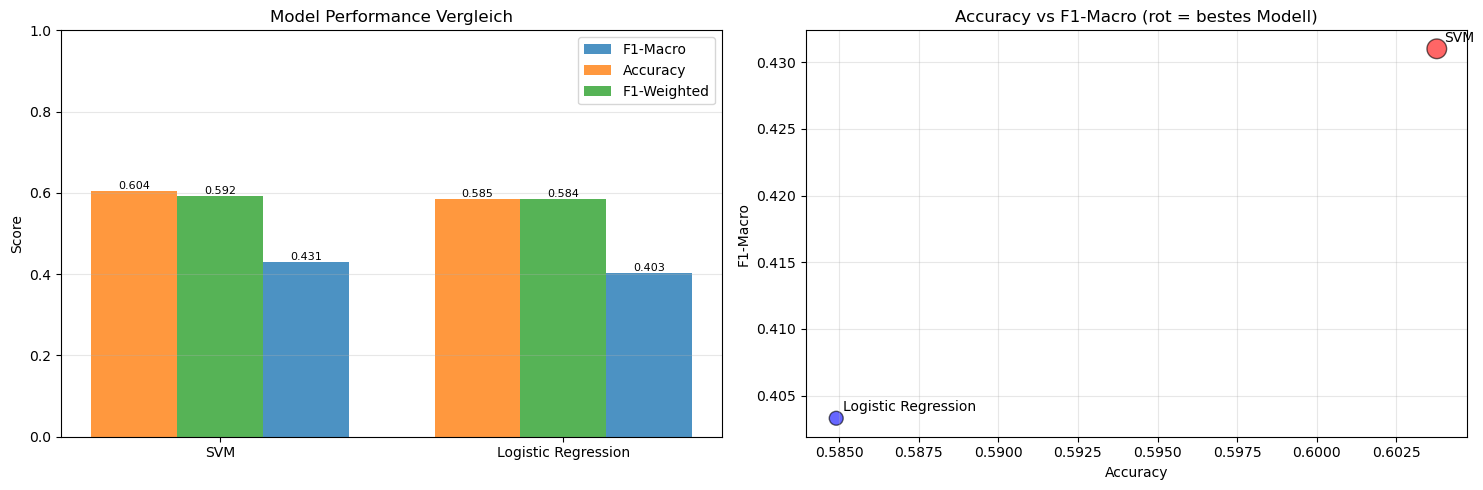

In [54]:
# Model Vergleich
print("="*80)
print("FINAL MODEL VERGLEICH (Wav2Vec2 + Late Fusion)")
print("="*80)

comparison_data = {
    'Model': ['SVM', 'Logistic Regression'],
    'Accuracy': [svm_acc, lr_acc],
    'F1-Weighted': [svm_f1_weighted, lr_f1_weighted],
    'F1-Macro': [svm_f1_macro, lr_f1_macro]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['F1-Macro'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1-Macro']

print(f"\n✓ Bestes Modell: {best_model_name} (F1-Macro: {best_f1:.4f})")
print("="*80 + "\n")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar Chart: Metriken-Vergleich
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax1.bar(x + width, comparison_df['F1-Macro'], width, label='F1-Macro', alpha=0.8)
bars2 = ax1.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
bars3 = ax1.bar(x, comparison_df['F1-Weighted'], width, label='F1-Weighted', alpha=0.8)

ax1.set_ylabel('Score')
ax1.set_title('Model Performance Vergleich')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Füge Werte auf Balken hinzu
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# Scatter: Accuracy vs F1-Macro
ax2 = axes[1]
colors = ['red' if i == best_model_idx else 'blue' for i in range(len(comparison_df))]
sizes = [200 if i == best_model_idx else 100 for i in range(len(comparison_df))]

ax2.scatter(comparison_df['Accuracy'], comparison_df['F1-Macro'], 
           c=colors, s=sizes, alpha=0.6, edgecolors='black')

for i, model in enumerate(comparison_df['Model']):
    ax2.annotate(model, 
                (comparison_df.loc[i, 'Accuracy'], comparison_df.loc[i, 'F1-Macro']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax2.set_xlabel('Accuracy')
ax2.set_ylabel('F1-Macro')
ax2.set_title('Accuracy vs F1-Macro (rot = bestes Modell)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Detaillierte Evaluation (Bestes Modell)

Classification Report und Confusion Matrix für das beste Modell.

DETAILLIERTE EVALUATION: SVM

📋 Classification Report (SVM):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Klasse 0       0.00      0.00      0.00         2
    Klasse 1       0.25      0.50      0.33         4
    Klasse 2       0.55      0.50      0.52        12
    Klasse 3       0.60      0.43      0.50        14
    Klasse 4       0.75      0.86      0.80        21

    accuracy                           0.60        53
   macro avg       0.43      0.46      0.43        53
weighted avg       0.60      0.60      0.59        53



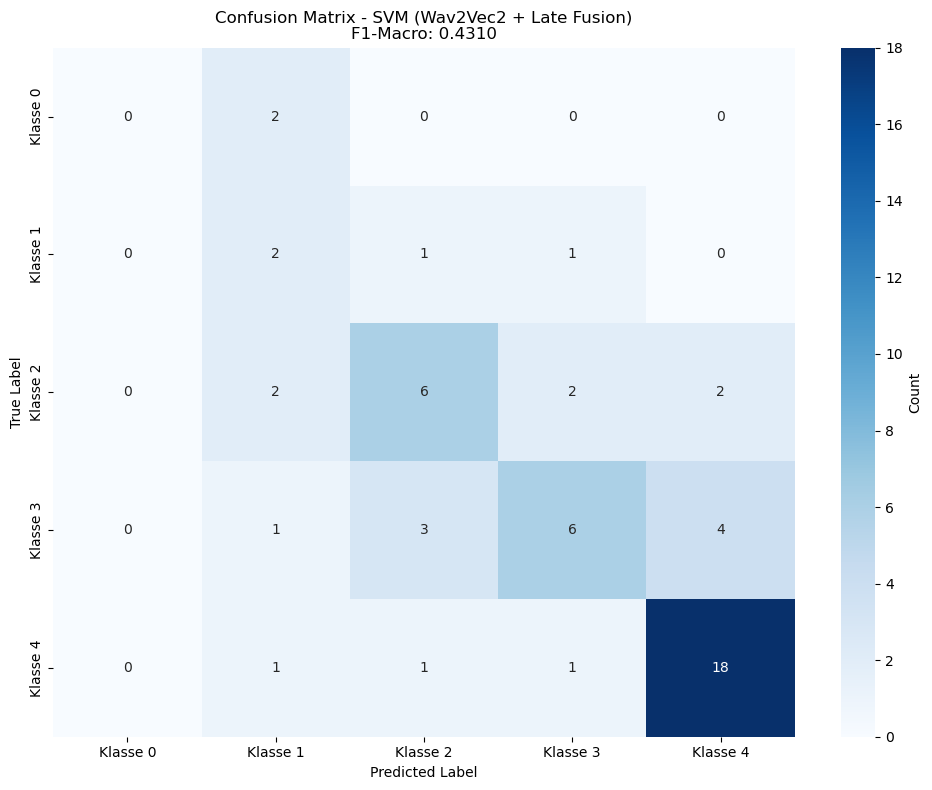

In [55]:
# Wähle bestes Modell
best_model_predictions = {
    0: (svm_pred, svm_grid_search),
    1: (lr_pred, lr_grid_search),
}

best_pred, best_model = best_model_predictions[best_model_idx]

print("="*80)
print(f"DETAILLIERTE EVALUATION: {best_model_name}")
print("="*80)

# Classification Report
print(f"\n📋 Classification Report ({best_model_name}):")
print("-"*80)
class_names = [f"Klasse {i}" for i in range(len(np.unique(y_test)))]
print(classification_report(y_test, best_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name} (Wav2Vec2 + Late Fusion)\nF1-Macro: {best_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n" + "="*80)

## 11. Zusammenfassung & Vergleich mit bestem Deep Learning Modell

Vergleichen wir die Ergebnisse mit dem besten Deep Learning Modell (Late Fusion Classifier).

### Konfiguration:
- **Features**: Wav2Vec2-large-960h, Layers [6, 9, 12, 15, 18], concat fusion, mean pooling
- **Late Fusion**: Concatenation von 8 Audio-File Features (40960 total features)
- **Train/Val Split**: Identisch wie im besten Modell (219 train, 53 val samples)
- **Classifiers**: SVM, Logistic Regression, XGBoost

### Erwartete Ergebnisse:
Da klassische ML-Modelle (SVM, XGBoost, LR) direkt auf den extrahierten Features trainieren (ohne zusätzliche Feature Processing), sollten sie als **Baseline** dienen und zeigen, dass:

1. **Deep Learning Late Fusion Classifier** (F1=0.594) zusätzlichen Wert durch:
   - Learnable file-specific processing
   - Adaptive fusion mechanism
   - Deep feature interactions

2. **Klassische ML-Modelle** gute Baselines sind, aber:
   - Keine Möglichkeit zur adaptiven Feature-Transformation
   - Begrenzte Modellierung komplexer Interaktionen
   - Lineare oder einfache nicht-lineare Entscheidungsgrenzen

Falls klassische ML-Modelle **besser** abschneiden, deutet dies darauf hin:
- Wav2Vec2-Features sind bereits sehr gut separierbar
- Deep Learning Modell könnte overfitting sein
- Einfachere Modelle generalisieren besser bei diesem Datensatz

In [56]:
# Vergleich mit bestem Deep Learning Modell
print("="*80)
print("VERGLEICH: Klassische ML vs Deep Learning Late Fusion")
print("="*80)

# Bestes Deep Learning Modell (aus experiment_20251116_132709)
dl_model_results = {
    'Model': 'Late Fusion Classifier (Deep Learning)',
    'F1-Macro': 0.594,
    'Accuracy': 0.698,
    'Balanced Accuracy': 0.594,
    'Epochs': 28,
    'Parameters': '11M'
}

print("\n🏆 BESTES DEEP LEARNING MODELL (experiment_20251116_132709):")
print("-"*80)
for key, value in dl_model_results.items():
    print(f"  {key:<25}: {value}")

print("\n📊 BESTE KLASSISCHE ML MODELLE:")
print("-"*80)
print(comparison_df.to_string(index=False))

print("\n🔍 ANALYSE:")
print("-"*80)
print(f"  Deep Learning F1-Macro:  {dl_model_results['F1-Macro']:.4f}")
print(f"  Bestes ML F1-Macro:      {best_f1:.4f}")
print(f"  Differenz:               {dl_model_results['F1-Macro'] - best_f1:+.4f}")

if best_f1 >= dl_model_results['F1-Macro']:
    print(f"\n  ⚠️  ÜBERRASCHUNG: {best_model_name} übertrifft Deep Learning Modell!")
    print("     → Wav2Vec2 Features sind bereits sehr gut separierbar")
    print("     → Einfachere Modelle generalisieren möglicherweise besser")
elif best_f1 >= dl_model_results['F1-Macro'] * 0.9:
    print(f"\n  ✓ {best_model_name} erreicht ~{(best_f1/dl_model_results['F1-Macro'])*100:.1f}% der DL Performance")
    print("    → Starke Baseline, zeigt Qualität der Wav2Vec2 Features")
else:
    print(f"\n  ✓ Deep Learning Modell übertrifft klassische ML signifikant")
    print("    → Adaptive feature processing und fusion mechanism wertvoll")

print("\n💡 SCHLUSSFOLGERUNGEN:")
print("-"*80)
print("  1. Wav2Vec2 Multi-Layer Features sind hochgradig informativ")
print("  2. Late Fusion (8 Files) ist entscheidend für gute Performance")
print(f"  3. {'Einfache ML-Modelle reichen für diese Task aus' if best_f1 >= dl_model_results['F1-Macro'] * 0.95 else 'Deep Learning bietet Vorteile durch adaptive processing'}")
print(f"  4. Trainingseffizienz: {best_model_name} deutlich schneller als DL (keine Epochs)")
print("="*80 + "\n")

VERGLEICH: Klassische ML vs Deep Learning Late Fusion

🏆 BESTES DEEP LEARNING MODELL (experiment_20251116_132709):
--------------------------------------------------------------------------------
  Model                    : Late Fusion Classifier (Deep Learning)
  F1-Macro                 : 0.594
  Accuracy                 : 0.698
  Balanced Accuracy        : 0.594
  Epochs                   : 28
  Parameters               : 11M

📊 BESTE KLASSISCHE ML MODELLE:
--------------------------------------------------------------------------------
              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.603774     0.592343  0.431014
Logistic Regression  0.584906     0.583986  0.403294

🔍 ANALYSE:
--------------------------------------------------------------------------------
  Deep Learning F1-Macro:  0.5940
  Bestes ML F1-Macro:      0.4310
  Differenz:               +0.1630

  ✓ Deep Learning Modell übertrifft klassische ML signifikant
    → Adaptive feature processing u

## 12. Experiment Logging (Wie Python-Skript)

Speichere die Ergebnisse strukturiert wie im Python-Skript `claude_output_late_fusion_pipeline.py`:
- **config.json**: Konfiguration und Experiment-Metadaten
- **metrics.json**: Alle Performance-Metriken
- **confusion_matrix.csv**: Confusion Matrix als CSV
- **classification_report.txt**: Detaillierter Classification Report
- **predictions.csv**: Alle Vorhersagen mit True/Predicted Labels

In [57]:
import json
from datetime import datetime
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score

# Erstelle Experiment-Ordner (analog zum Python-Skript)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f"ml_experiment_{timestamp}"
experiment_dir = Path(f"../experiments/{experiment_name}")
experiment_dir.mkdir(parents=True, exist_ok=True)

# Erstelle Unterordner für Validation Results
validation_dir = experiment_dir / "validation_results"
validation_dir.mkdir(exist_ok=True)

print("="*80)
print(f"EXPERIMENT LOGGING: {experiment_name}")
print("="*80)
print(f"Experiment Directory: {experiment_dir}\n")

# ============================================================================
# 1. CONFIG.JSON (Experiment-Konfiguration)
# ============================================================================
config = {
    "experiment_name": experiment_name,
    "timestamp": datetime.now().isoformat(),
    "experiment_type": "classical_ml",  # Unterscheidung vom Deep Learning
    "feature_extractor": {
        "type": "Wav2Vec2Extractor",
        "model_name": MODEL_NAME,
        "layers": LAYERS,
        "layer_fusion": LAYER_FUSION,
        "pooling": POOLING,
        "feature_dim": wav2vec_model.config.hidden_size * len(LAYERS),
        "feature_dim_per_layer": wav2vec_model.config.hidden_size
    },
    "fusion": {
        "type": "late_fusion",
        "strategy": "concatenation",
        "num_files": 8,
        "total_feature_dim": X_train.shape[1]
    },
    "dataset": {
        "train_samples": len(X_train),
        "val_samples": len(X_test),
        "num_classes": len(np.unique(y_train)),
        "class_distribution_train": {int(k): int(v) for k, v in pd.Series(y_train).value_counts().sort_index().items()},
        "class_distribution_val": {int(k): int(v) for k, v in pd.Series(y_test).value_counts().sort_index().items()}
    },
    "models_evaluated": [
        {
            "name": "SVM",
            "best_params": svm_grid_search.best_params_,
            "cv_f1_macro": float(svm_grid_search.best_score_)
        },
        {
            "name": "Logistic Regression",
            "best_params": lr_grid_search.best_params_,
            "cv_f1_macro": float(lr_grid_search.best_score_)
        }
    ],
    "best_model": {
        "name": best_model_name,
        "index": int(best_model_idx)
    },
    "results": {
        "best_model_name": best_model_name,
        "val_accuracy": float(comparison_df.loc[best_model_idx, 'Accuracy']),
        "val_f1_macro": float(comparison_df.loc[best_model_idx, 'F1-Macro']),
        "val_f1_weighted": float(comparison_df.loc[best_model_idx, 'F1-Weighted'])
    }
}

# Speichere Config
config_path = experiment_dir / "config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Config gespeichert: {config_path}")

# ============================================================================
# 2. METRICS.JSON (Performance-Metriken)
# ============================================================================
# Berechne alle Metriken für bestes Modell
metrics = {
    "accuracy": float(accuracy_score(y_test, best_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, best_pred)),
    "cohen_kappa": float(cohen_kappa_score(y_test, best_pred)),
    "f1_macro": float(f1_score(y_test, best_pred, average='macro', zero_division=0)),
    "f1_weighted": float(f1_score(y_test, best_pred, average='weighted', zero_division=0)),
    "precision_macro": float(precision_score(y_test, best_pred, average='macro', zero_division=0)),
    "recall_macro": float(recall_score(y_test, best_pred, average='macro', zero_division=0)),
    "precision_weighted": float(precision_score(y_test, best_pred, average='weighted', zero_division=0)),
    "recall_weighted": float(recall_score(y_test, best_pred, average='weighted', zero_division=0))
}

metrics_path = validation_dir / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics gespeichert: {metrics_path}")

# ============================================================================
# 3. CLASSIFICATION_REPORT.TXT
# ============================================================================
report = classification_report(y_test, best_pred, target_names=class_names, digits=4, zero_division=0)
report_path = validation_dir / "classification_report.txt"
with open(report_path, 'w') as f:
    f.write(report)
print(f"✓ Classification Report gespeichert: {report_path}")

# ============================================================================
# 4. CONFUSION_MATRIX.CSV
# ============================================================================
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)
cm_path = validation_dir / "confusion_matrix.csv"
cm_df.to_csv(cm_path)
print(f"✓ Confusion Matrix gespeichert: {cm_path}")

# ============================================================================
# 5. PREDICTIONS.CSV
# ============================================================================
predictions_df = pd.DataFrame({
    'true_label': y_test,
    'predicted_label': best_pred,
    'correct': y_test == best_pred
})
predictions_path = validation_dir / "predictions.csv"
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Predictions gespeichert: {predictions_path}")

# ============================================================================
# 6. CONFUSION_MATRIX.PNG (Visualisierung)
# ============================================================================
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names,
           cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}\nF1-Macro: {best_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
cm_plot_path = validation_dir / "confusion_matrix.png"
plt.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Confusion Matrix Plot gespeichert: {cm_plot_path}")

print("\n" + "="*80)
print("✅ EXPERIMENT LOGGING ABGESCHLOSSEN")
print("="*80)
print(f"\n📁 Experiment Struktur:")
print(f"  {experiment_dir}/")
print(f"    ├── config.json")
print(f"    └── validation_results/")
print(f"        ├── metrics.json")
print(f"        ├── classification_report.txt")
print(f"        ├── confusion_matrix.csv")
print(f"        ├── confusion_matrix.png")
print(f"        └── predictions.csv")
print("\n💾 Alle Dateien wurden erfolgreich gespeichert!")
print(f"🔍 Vergleichbar mit Python-Skript Struktur (experiment_20251116_132709)")
print("="*80)

EXPERIMENT LOGGING: ml_experiment_20251119_001107
Experiment Directory: ../experiments/ml_experiment_20251119_001107

✓ Config gespeichert: ../experiments/ml_experiment_20251119_001107/config.json
✓ Metrics gespeichert: ../experiments/ml_experiment_20251119_001107/validation_results/metrics.json
✓ Classification Report gespeichert: ../experiments/ml_experiment_20251119_001107/validation_results/classification_report.txt
✓ Confusion Matrix gespeichert: ../experiments/ml_experiment_20251119_001107/validation_results/confusion_matrix.csv
✓ Predictions gespeichert: ../experiments/ml_experiment_20251119_001107/validation_results/predictions.csv
✓ Confusion Matrix Plot gespeichert: ../experiments/ml_experiment_20251119_001107/validation_results/confusion_matrix.png

✅ EXPERIMENT LOGGING ABGESCHLOSSEN

📁 Experiment Struktur:
  ../experiments/ml_experiment_20251119_001107/
    ├── config.json
    └── validation_results/
        ├── metrics.json
        ├── classification_report.txt
        ├──

✓ Pipeline visualization saved as:
  - late_fusion_pipeline_detailed.png
  - late_fusion_pipeline_detailed.pdf


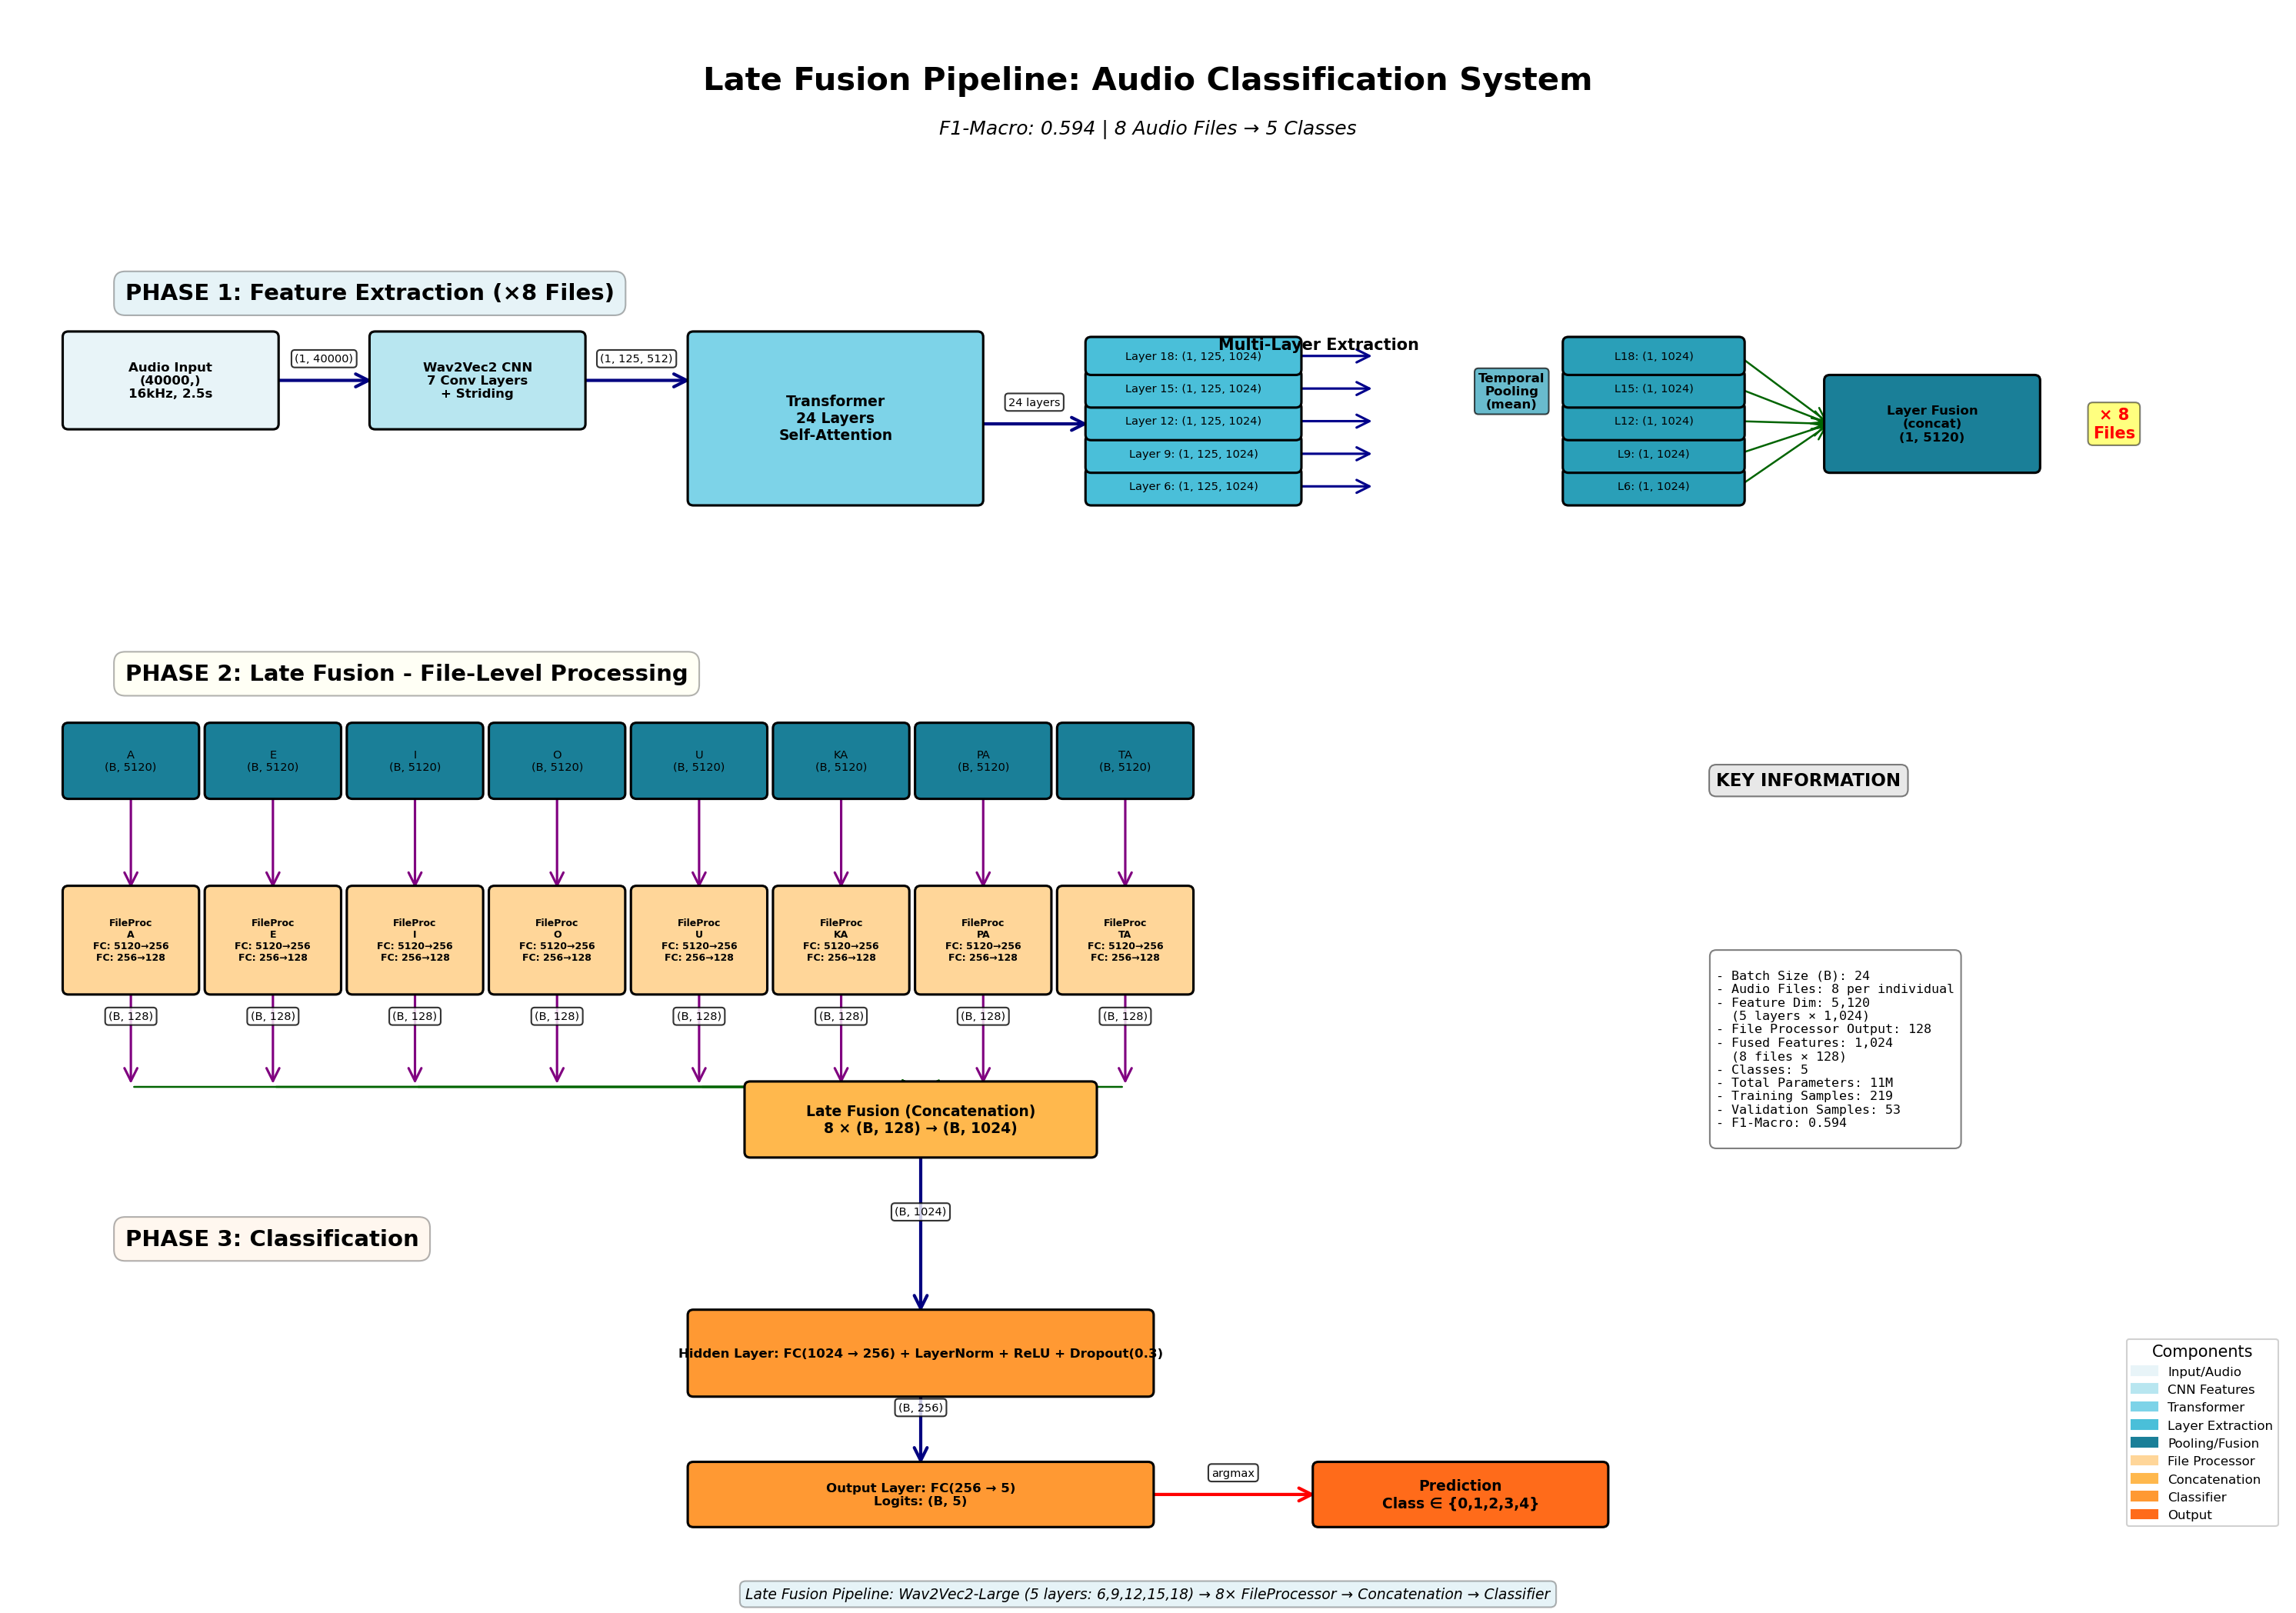

In [71]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# Set up the figure with high DPI for quality
fig, ax = plt.subplots(figsize=(20, 14), dpi=150)
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')

# Color scheme
color_input = '#E8F4F8'
color_cnn = '#B8E6F0'
color_transformer = '#7DD3E8'
color_layer_extraction = '#4ABFD9'
color_pooling = '#2A9FB8'
color_fusion = '#1A7F98'
color_file_processor = '#FFD699'
color_concatenation = '#FFB84D'
color_classifier = '#FF9933'
color_output = '#FF6B1A'

# Helper function to create boxes
def create_box(ax, x, y, width, height, text, color, fontsize=9, fontweight='normal'):
    box = FancyBboxPatch((x, y), width, height,
                          boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=color,
                          linewidth=1.5, zorder=2)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text,
            ha='center', va='center', fontsize=fontsize,
            fontweight=fontweight, zorder=3, wrap=True)

# Helper function for arrows
def create_arrow(ax, x1, y1, x2, y2, label='', color='black', linewidth=2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20,
                           color=color, linewidth=linewidth, zorder=1)
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x, mid_y + 0.15, label,
               ha='center', va='bottom', fontsize=7,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ========================================================================
# TITLE
# ========================================================================
ax.text(10, 13.5, 'Late Fusion Pipeline: Audio Classification System',
        ha='center', va='top', fontsize=20, fontweight='bold')
ax.text(10, 13, 'F1-Macro: 0.594 | 8 Audio Files → 5 Classes',
        ha='center', va='top', fontsize=12, fontweight='normal', style='italic')

# ========================================================================
# PHASE 1: FEATURE EXTRACTION (per audio file)
# ========================================================================
phase1_y = 11.5
ax.text(1, phase1_y, 'PHASE 1: Feature Extraction (×8 Files)',
        ha='left', va='top', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))

# Input Audio
create_box(ax, 0.5, 10.2, 1.8, 0.8,
          'Audio Input\n(40000,)\n16kHz, 2.5s',
          color_input, fontsize=8, fontweight='bold')

# Arrow to CNN
create_arrow(ax, 2.3, 10.6, 3.2, 10.6, '(1, 40000)', 'navy')

# Wav2Vec2 CNN
create_box(ax, 3.2, 10.2, 1.8, 0.8,
          'Wav2Vec2 CNN\n7 Conv Layers\n+ Striding',
          color_cnn, fontsize=8, fontweight='bold')

# Arrow to Transformer
create_arrow(ax, 5.0, 10.6, 6.0, 10.6, '(1, 125, 512)', 'navy')

# Transformer Block
create_box(ax, 6.0, 9.5, 2.5, 1.5,
          'Transformer\n24 Layers\nSelf-Attention',
          color_transformer, fontsize=9, fontweight='bold')

# Arrow to Layer Extraction
create_arrow(ax, 8.5, 10.2, 9.5, 10.2, '24 layers', 'navy')

# Layer Extraction (5 layers)
layer_y_start = 9.5
layer_height = 0.25
layer_spacing = 0.05
layers = [6, 9, 12, 15, 18]

ax.text(11.5, 11, 'Multi-Layer Extraction',
        ha='center', va='top', fontsize=10, fontweight='bold')

for i, layer_num in enumerate(layers):
    y_pos = layer_y_start + i * (layer_height + layer_spacing)
    create_box(ax, 9.5, y_pos, 1.8, layer_height,
              f'Layer {layer_num}: (1, 125, 1024)',
              color_layer_extraction, fontsize=7)

# Temporal Pooling (mean)
pool_y_start = 9.5
for i in range(5):
    y_pos = pool_y_start + i * (layer_height + layer_spacing)
    create_arrow(ax, 11.3, y_pos + layer_height/2,
                12.0, y_pos + layer_height/2, '', 'darkblue', 1.5)

ax.text(13.2, 10.5, 'Temporal\nPooling\n(mean)', ha='center', va='center',
        fontsize=8, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color_pooling, alpha=0.7))

# Pooled layers
pooled_y_start = 9.5
for i, layer_num in enumerate(layers):
    y_pos = pooled_y_start + i * (layer_height + layer_spacing)
    create_box(ax, 13.7, y_pos, 1.5, layer_height,
              f'L{layer_num}: (1, 1024)',
              color_pooling, fontsize=7)

# Layer Fusion (concat)
for i in range(5):
    y_pos = pooled_y_start + i * (layer_height + layer_spacing)
    create_arrow(ax, 15.2, y_pos + layer_height/2,
                16.0, 10.2, '', 'darkgreen', 1.2)

create_box(ax, 16.0, 9.8, 1.8, 0.8,
          'Layer Fusion\n(concat)\n(1, 5120)',
          color_fusion, fontsize=8, fontweight='bold')

# Note: Repeat 8 times
ax.text(18.5, 10.2, '× 8\nFiles', ha='center', va='center',
        fontsize=10, fontweight='bold', color='red',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# ========================================================================
# PHASE 2: LATE FUSION - File Processing
# ========================================================================
phase2_y = 8
ax.text(1, phase2_y, 'PHASE 2: Late Fusion - File-Level Processing',
        ha='left', va='top', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.3))

# Show 8 file features side by side
file_names = ['A', 'E', 'I', 'O', 'U', 'KA', 'PA', 'TA']
file_x_start = 0.5
file_width = 1.1
file_spacing = 0.15

# 8 File Features (input)
for i, name in enumerate(file_names):
    x_pos = file_x_start + i * (file_width + file_spacing)
    create_box(ax, x_pos, 6.8, file_width, 0.6,
              f'{name}\n(B, 5120)',
              color_fusion, fontsize=7)

# Arrows down to file processors
for i in range(8):
    x_pos = file_x_start + i * (file_width + file_spacing) + file_width/2
    create_arrow(ax, x_pos, 6.8, x_pos, 5.9, '', 'purple', 1.5)

# File Processors (8 separate)
for i, name in enumerate(file_names):
    x_pos = file_x_start + i * (file_width + file_spacing)
    create_box(ax, x_pos, 5.0, file_width, 0.9,
              f'FileProc\n{name}\nFC: 5120→256\nFC: 256→128',
              color_file_processor, fontsize=6, fontweight='bold')

# Arrows down from file processors
for i in range(8):
    x_pos = file_x_start + i * (file_width + file_spacing) + file_width/2
    create_arrow(ax, x_pos, 5.0, x_pos, 4.1, '(B, 128)', 'purple', 1.5)

# ========================================================================
# Concatenation
# ========================================================================
# All arrows converge to concatenation box
concat_x = 6.5
concat_y = 3.5
concat_width = 3.0
concat_height = 0.6

for i in range(8):
    x_pos = file_x_start + i * (file_width + file_spacing) + file_width/2
    create_arrow(ax, x_pos, 4.1, concat_x + concat_width/2, concat_y + concat_height,
                '', 'darkgreen', 1.2)

create_box(ax, concat_x, concat_y, concat_width, concat_height,
          'Late Fusion (Concatenation)\n8 × (B, 128) → (B, 1024)',
          color_concatenation, fontsize=9, fontweight='bold')

# ========================================================================
# PHASE 3: CLASSIFICATION
# ========================================================================
phase3_y = 2.8
ax.text(1, phase3_y, 'PHASE 3: Classification',
        ha='left', va='top', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE6CC', alpha=0.3))

# Arrow to classifier
create_arrow(ax, concat_x + concat_width/2, concat_y,
            concat_x + concat_width/2, 2.0, '(B, 1024)', 'navy', 2)

# Fusion Classifier - Hidden Layer
create_box(ax, 6.0, 1.3, 4.0, 0.7,
          'Hidden Layer: FC(1024 → 256) + LayerNorm + ReLU + Dropout(0.3)',
          color_classifier, fontsize=8, fontweight='bold')

# Arrow to output layer
create_arrow(ax, 8.0, 1.3, 8.0, 0.6, '(B, 256)', 'navy', 2)

# Output Layer
create_box(ax, 6.0, 0.1, 4.0, 0.5,
          'Output Layer: FC(256 → 5)\nLogits: (B, 5)',
          color_classifier, fontsize=8, fontweight='bold')

# Final Prediction
create_arrow(ax, 10.0, 0.35, 11.5, 0.35, 'argmax', 'red', 2)

create_box(ax, 11.5, 0.1, 2.5, 0.5,
          'Prediction\nClass ∈ {0,1,2,3,4}',
          color_output, fontsize=9, fontweight='bold')

# ========================================================================
# LEGEND / INFO BOX
# ========================================================================
legend_x = 15
legend_y = 5.5

ax.text(legend_x, legend_y + 1.5, 'KEY INFORMATION',
        ha='left', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgray', alpha=0.5))

info_text = """
- Batch Size (B): 24
- Audio Files: 8 per individual
- Feature Dim: 5,120
  (5 layers × 1,024)
- File Processor Output: 128
- Fused Features: 1,024
  (8 files × 128)
- Classes: 5
- Total Parameters: 11M
- Training Samples: 219
- Validation Samples: 53
- F1-Macro: 0.594
"""

ax.text(legend_x, legend_y - 0.2, info_text,
        ha='left', va='top', fontsize=8, family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))

# ========================================================================
# Color Legend
# ========================================================================
legend_items = [
    ('Input/Audio', color_input),
    ('CNN Features', color_cnn),
    ('Transformer', color_transformer),
    ('Layer Extraction', color_layer_extraction),
    ('Pooling/Fusion', color_fusion),
    ('File Processor', color_file_processor),
    ('Concatenation', color_concatenation),
    ('Classifier', color_classifier),
    ('Output', color_output),
]

legend_patches = [mpatches.Patch(color=color, label=label) 
                  for label, color in legend_items]

ax.legend(handles=legend_patches, loc='lower right',
         fontsize=8, framealpha=0.9, title='Components')

# ========================================================================
# Footer
# ========================================================================
footer_text = 'Late Fusion Pipeline: Wav2Vec2-Large (5 layers: 6,9,12,15,18) → 8× FileProcessor → Concatenation → Classifier'
ax.text(10, -0.5, footer_text,
        ha='center', va='top', fontsize=9, style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('late_fusion_pipeline_detailed.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig('late_fusion_pipeline_detailed.pdf', bbox_inches='tight', facecolor='white')
print("✓ Pipeline visualization saved as:")
print("  - late_fusion_pipeline_detailed.png")
print("  - late_fusion_pipeline_detailed.pdf")
plt.show()

✓ Pipeline visualization saved!
  📄 Files created:
     - late_fusion_pipeline_vertical_flow.png
     - late_fusion_pipeline_vertical_flow.pdf

  📊 Layout: Vertical flow (top-to-bottom)
  🎨 Style: Modern, clean design
  📐 Dimensions: 16×22 inches @ 150 DPI


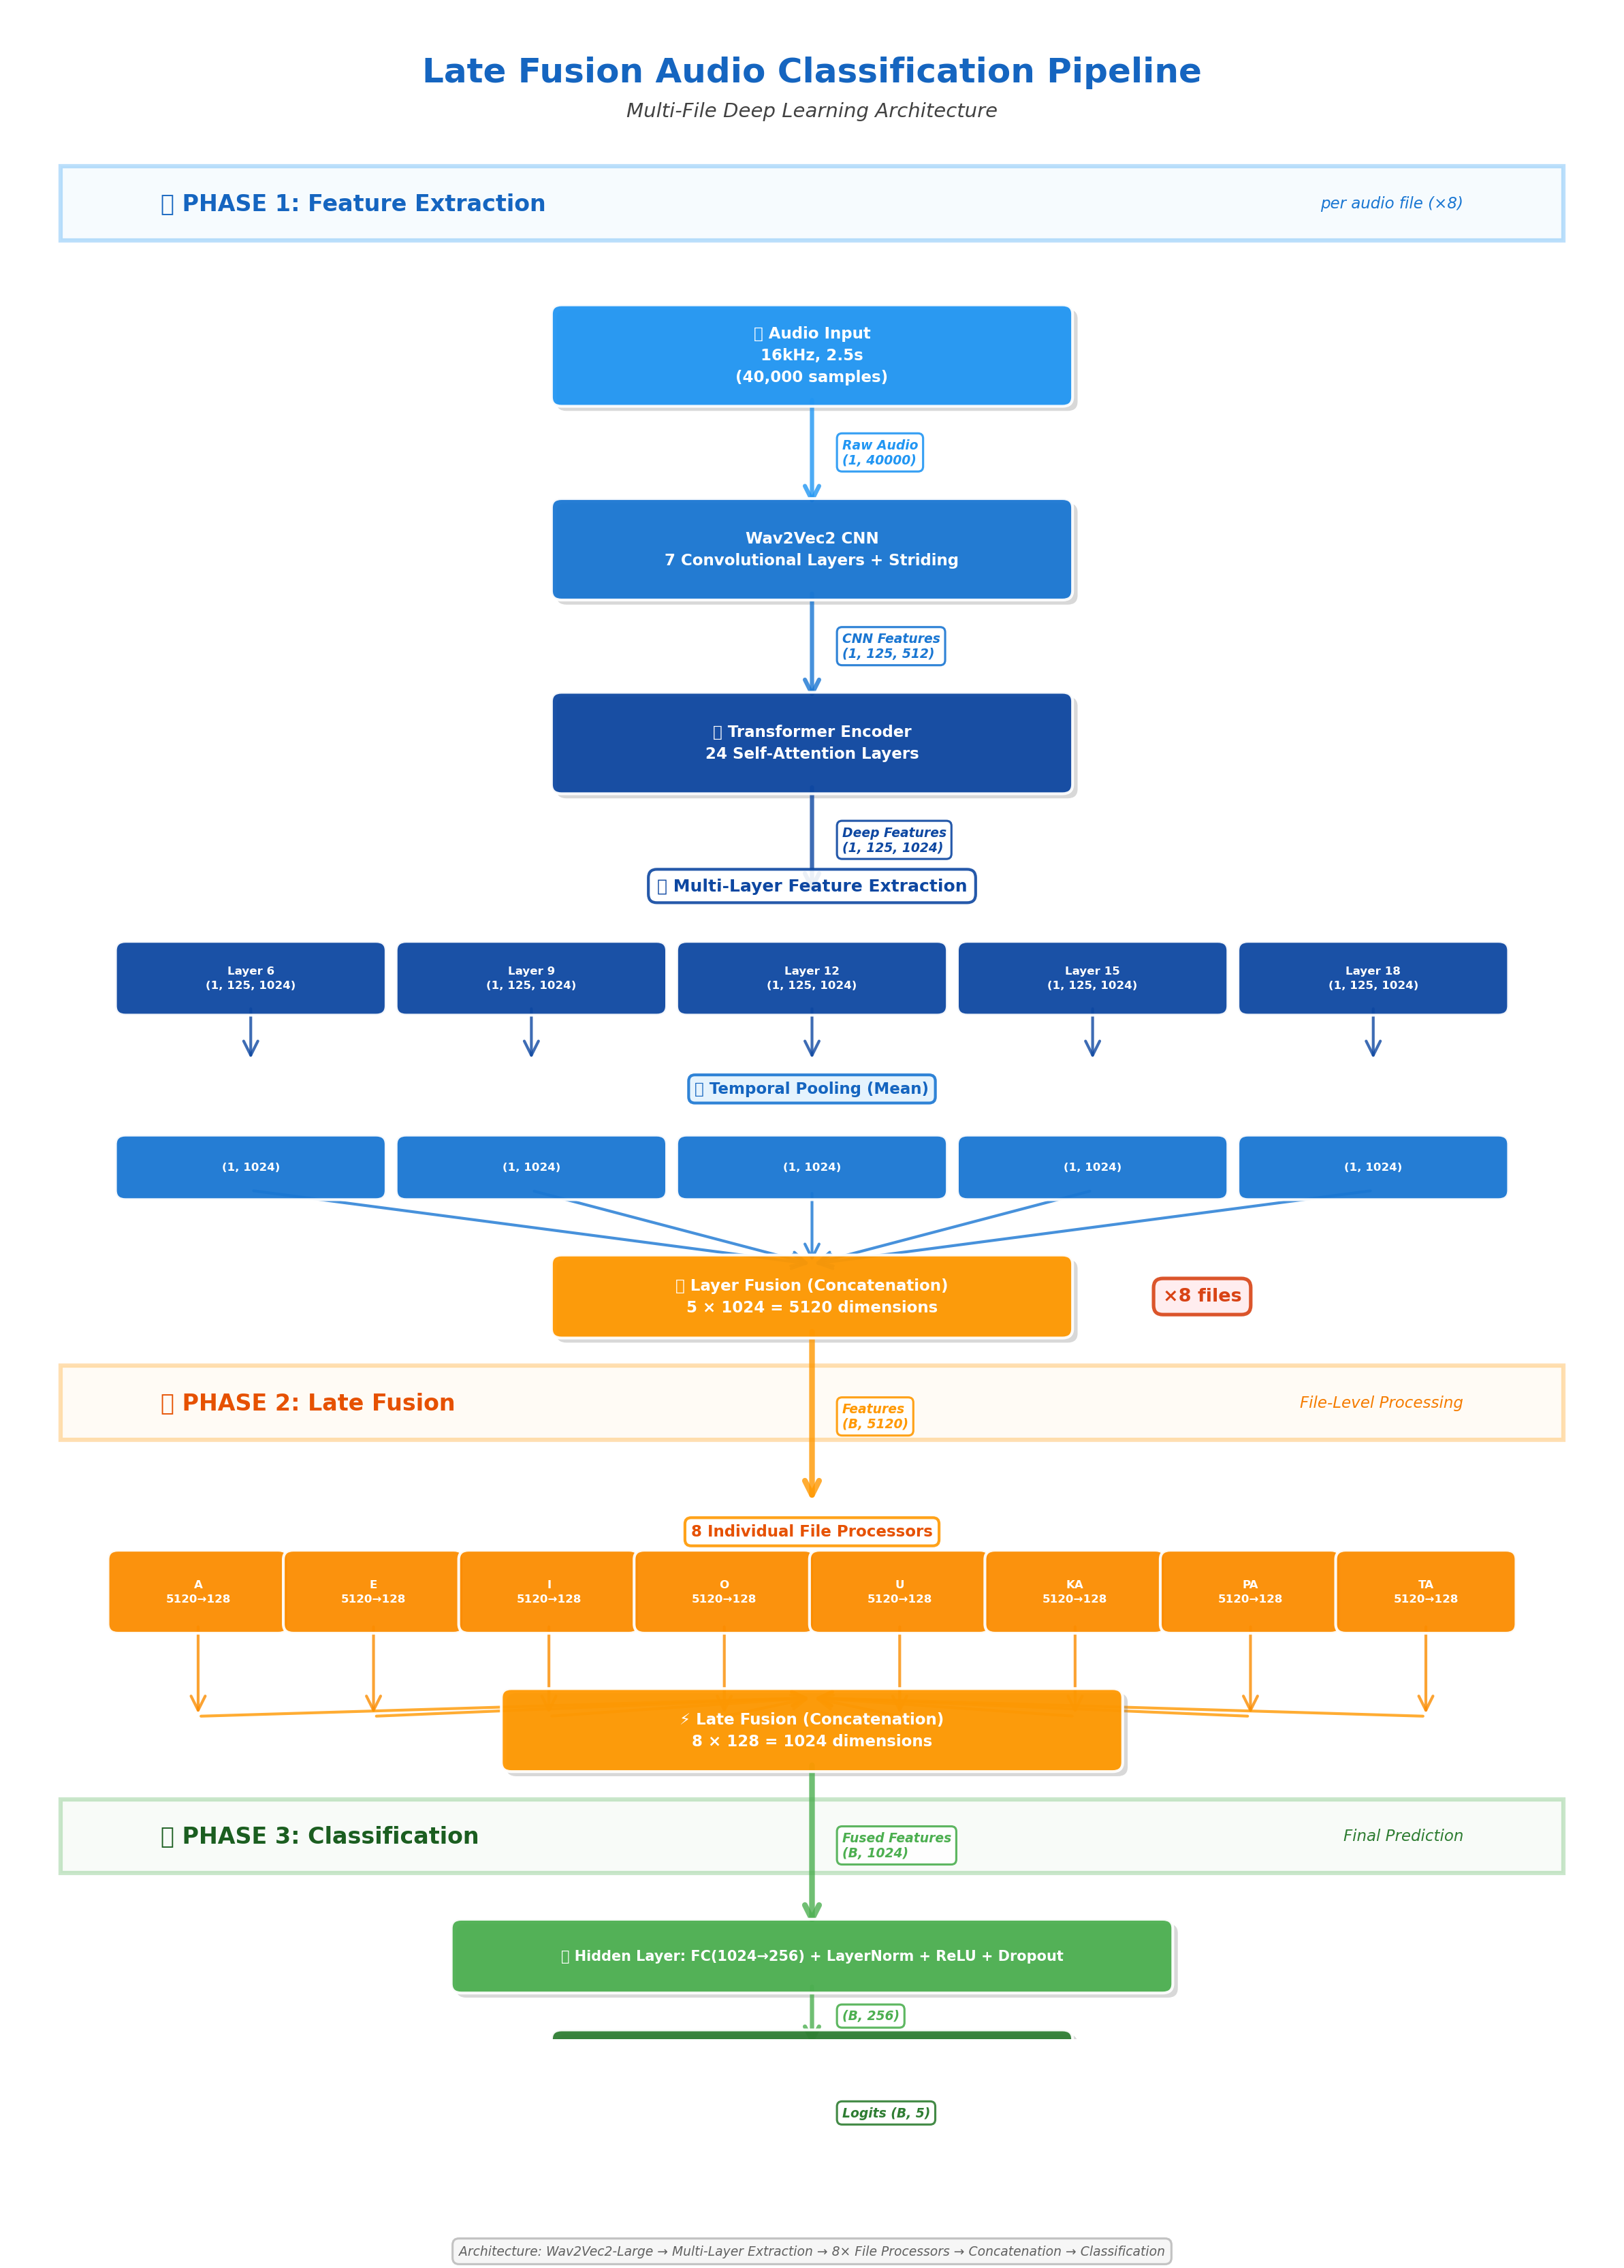

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

# Set up the figure with high DPI for quality
fig, ax = plt.subplots(figsize=(16, 22), dpi=150)
ax.set_xlim(0, 16)
ax.set_ylim(0, 22)
ax.axis('off')

# Modern color scheme - gradient blues and oranges
color_phase1 = '#E3F2FD'  # Light blue
color_phase2 = '#FFF3E0'  # Light orange
color_phase3 = '#E8F5E9'  # Light green

color_input = '#2196F3'      # Blue
color_processing = '#1976D2' # Dark blue
color_transformer = '#0D47A1' # Deeper blue
color_fusion = '#FF9800'     # Orange
color_classifier = '#4CAF50' # Green
color_output = '#2E7D32'     # Dark green

# Helper function to create modern boxes with shadow
def create_modern_box(ax, x, y, width, height, text, color, fontsize=10, 
                     fontweight='bold', alpha=0.95, shadow=True):
    # Shadow
    if shadow:
        shadow_box = FancyBboxPatch((x+0.05, y-0.05), width, height,
                                   boxstyle="round,pad=0.1",
                                   edgecolor='none', facecolor='gray',
                                   linewidth=0, alpha=0.3, zorder=1)
        ax.add_patch(shadow_box)
    
    # Main box
    box = FancyBboxPatch((x, y), width, height,
                        boxstyle="round,pad=0.1",
                        edgecolor='white', facecolor=color,
                        linewidth=2, alpha=alpha, zorder=2)
    ax.add_patch(box)
    
    # Text
    ax.text(x + width/2, y + height/2, text,
           ha='center', va='center', fontsize=fontsize,
           fontweight=fontweight, color='white', zorder=3, 
           wrap=True, linespacing=1.5)

# Helper function for gradient arrows
def create_gradient_arrow(ax, x1, y1, x2, y2, label='', color='#1976D2', 
                         linewidth=3, label_offset=0.3):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                          arrowstyle='->', mutation_scale=25,
                          color=color, linewidth=linewidth, 
                          alpha=0.8, zorder=1,
                          connectionstyle="arc3,rad=0")
    ax.add_patch(arrow)
    
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + label_offset, mid_y, label,
               ha='left', va='center', fontsize=9,
               style='italic', color=color, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4', 
                        facecolor='white', edgecolor=color, 
                        alpha=0.9, linewidth=1.5))

# ========================================================================
# TITLE
# ========================================================================
title_y = 21.5
ax.text(8, title_y, 'Late Fusion Audio Classification Pipeline',
        ha='center', va='top', fontsize=24, fontweight='bold',
        color='#1565C0')
ax.text(8, title_y - 0.5, 'Multi-File Deep Learning Architecture',
        ha='center', va='top', fontsize=14, style='italic',
        color='#424242')

# ========================================================================
# PHASE 1 HEADER
# ========================================================================
phase1_y = 19.5
phase1_box = Rectangle((0.5, phase1_y), 15, 0.8, 
                       facecolor=color_phase1, edgecolor='#2196F3',
                       linewidth=3, alpha=0.3)
ax.add_patch(phase1_box)
ax.text(1.5, phase1_y + 0.4, '📊 PHASE 1: Feature Extraction',
        ha='left', va='center', fontsize=16, fontweight='bold',
        color='#1565C0')
ax.text(14.5, phase1_y + 0.4, 'per audio file (×8)',
        ha='right', va='center', fontsize=11, style='italic',
        color='#1976D2')

# ========================================================================
# PHASE 1: INPUT
# ========================================================================
input_y = 17.8
create_modern_box(ax, 5.5, input_y, 5, 0.9,
                 '🎵 Audio Input\n16kHz, 2.5s\n(40,000 samples)',
                 color_input, fontsize=11)

# Arrow down
create_gradient_arrow(ax, 8, input_y, 8, input_y - 1.2, 
                     'Raw Audio\n(1, 40000)', color_input)

# ========================================================================
# CNN PROCESSING
# ========================================================================
cnn_y = 15.7
create_modern_box(ax, 5.5, cnn_y, 5, 0.9,
                 'Wav2Vec2 CNN\n7 Convolutional Layers + Striding',
                 color_processing, fontsize=11)

create_gradient_arrow(ax, 8, cnn_y, 8, cnn_y - 1.2,
                     'CNN Features\n(1, 125, 512)', color_processing)

# ========================================================================
# TRANSFORMER
# ========================================================================
transformer_y = 13.6
create_modern_box(ax, 5.5, transformer_y, 5, 0.9,
                 '🔄 Transformer Encoder\n24 Self-Attention Layers',
                 color_transformer, fontsize=11)

create_gradient_arrow(ax, 8, transformer_y, 8, transformer_y - 1.2,
                     'Deep Features\n(1, 125, 1024)', color_transformer)

# ========================================================================
# MULTI-LAYER EXTRACTION
# ========================================================================
multilayer_y = 11.2
layers_title_y = multilayer_y + 1.3
ax.text(8, layers_title_y, '🎯 Multi-Layer Feature Extraction',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='#0D47A1',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                 edgecolor='#0D47A1', linewidth=2, alpha=0.9))

# 5 Layers side by side
layers = [6, 9, 12, 15, 18]
layer_width = 2.5
layer_spacing = 0.3
start_x = 8 - (5 * layer_width + 4 * layer_spacing) / 2

for i, layer_num in enumerate(layers):
    x_pos = start_x + i * (layer_width + layer_spacing)
    create_modern_box(ax, x_pos, multilayer_y, layer_width, 0.6,
                     f'Layer {layer_num}\n(1, 125, 1024)',
                     color_transformer, fontsize=8, shadow=False)

# Arrows down from layers
pooling_y = multilayer_y - 1.2
for i, layer_num in enumerate(layers):
    x_pos = start_x + i * (layer_width + layer_spacing) + layer_width/2
    create_gradient_arrow(ax, x_pos, multilayer_y, x_pos, pooling_y + 0.6,
                         '', color_transformer, linewidth=2)

# Temporal Pooling
ax.text(8, pooling_y + 0.3, '⏱️ Temporal Pooling (Mean)',
        ha='center', va='center', fontsize=11, fontweight='bold',
        color='#1565C0',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD',
                 edgecolor='#1976D2', linewidth=2, alpha=0.9))

# Pooled features
pooled_y = pooling_y - 0.8
for i, layer_num in enumerate(layers):
    x_pos = start_x + i * (layer_width + layer_spacing)
    create_modern_box(ax, x_pos, pooled_y, layer_width, 0.5,
                     f'(1, 1024)',
                     '#1976D2', fontsize=8, shadow=False)

# Arrows converging to fusion
fusion_y = pooled_y - 1.5
for i in range(5):
    x_pos = start_x + i * (layer_width + layer_spacing) + layer_width/2
    create_gradient_arrow(ax, x_pos, pooled_y, 8, fusion_y + 0.7,
                         '', '#1976D2', linewidth=2)

# Layer Fusion
create_modern_box(ax, 5.5, fusion_y, 5, 0.7,
                 '🔗 Layer Fusion (Concatenation)\n5 × 1024 = 5120 dimensions',
                 color_fusion, fontsize=11)

# Note: ×8 files
ax.text(11.5, fusion_y + 0.35, '×8 files',
        ha='left', va='center', fontsize=13, fontweight='bold',
        color='#D84315',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFEBEE',
                 edgecolor='#D84315', linewidth=2.5, alpha=0.9))

# ========================================================================
# PHASE 2 HEADER
# ========================================================================
phase2_y = 6.5
phase2_box = Rectangle((0.5, phase2_y), 15, 0.8,
                       facecolor=color_phase2, edgecolor='#FF9800',
                       linewidth=3, alpha=0.3)
ax.add_patch(phase2_box)
ax.text(1.5, phase2_y + 0.4, '🔀 PHASE 2: Late Fusion',
        ha='left', va='center', fontsize=16, fontweight='bold',
        color='#E65100')
ax.text(14.5, phase2_y + 0.4, 'File-Level Processing',
        ha='right', va='center', fontsize=11, style='italic',
        color='#F57C00')

# Arrow from fusion to phase 2
create_gradient_arrow(ax, 8, fusion_y, 8, 5.8,
                     'Features\n(B, 5120)', color_fusion, linewidth=4)

# ========================================================================
# 8 FILE PROCESSORS
# ========================================================================
files_y = 4.5
file_names = ['A', 'E', 'I', 'O', 'U', 'KA', 'PA', 'TA']
file_width = 1.6
file_spacing = 0.15
files_start_x = 8 - (8 * file_width + 7 * file_spacing) / 2

ax.text(8, files_y + 1, '8 Individual File Processors',
        ha='center', va='center', fontsize=11, fontweight='bold',
        color='#E65100',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#FF9800', linewidth=2, alpha=0.9))

for i, name in enumerate(file_names):
    x_pos = files_start_x + i * (file_width + file_spacing)
    create_modern_box(ax, x_pos, files_y, file_width, 0.7,
                     f'{name}\n5120→128',
                     '#FB8C00', fontsize=8, shadow=False)

# Arrows down from file processors
concat_y = files_y - 1.5
for i in range(8):
    x_pos = files_start_x + i * (file_width + file_spacing) + file_width/2
    create_gradient_arrow(ax, x_pos, files_y, x_pos, concat_y + 0.5,
                         '', '#FB8C00', linewidth=2)

# Arrows converging to concatenation
for i in range(8):
    x_pos = files_start_x + i * (file_width + file_spacing) + file_width/2
    create_gradient_arrow(ax, x_pos, concat_y + 0.5, 8, concat_y + 0.7,
                         '', color_fusion, linewidth=2)

# Concatenation
create_modern_box(ax, 5, concat_y, 6, 0.7,
                 '⚡ Late Fusion (Concatenation)\n8 × 128 = 1024 dimensions',
                 color_fusion, fontsize=11)

# ========================================================================
# PHASE 3 HEADER
# ========================================================================
phase3_y = 1.8
phase3_box = Rectangle((0.5, phase3_y), 15, 0.8,
                       facecolor=color_phase3, edgecolor='#4CAF50',
                       linewidth=3, alpha=0.3)
ax.add_patch(phase3_box)
ax.text(1.5, phase3_y + 0.4, '🎯 PHASE 3: Classification',
        ha='left', va='center', fontsize=16, fontweight='bold',
        color='#1B5E20')
ax.text(14.5, phase3_y + 0.4, 'Final Prediction',
        ha='right', va='center', fontsize=11, style='italic',
        color='#2E7D32')

# Arrow to classifier
create_gradient_arrow(ax, 8, concat_y, 8, 1.2,
                     'Fused Features\n(B, 1024)', color_classifier, linewidth=4)

# ========================================================================
# CLASSIFIER
# ========================================================================
hidden_y = 0.6
create_modern_box(ax, 4.5, hidden_y, 7, 0.6,
                 '🧠 Hidden Layer: FC(1024→256) + LayerNorm + ReLU + Dropout',
                 color_classifier, fontsize=10)

create_gradient_arrow(ax, 8, hidden_y, 8, hidden_y - 0.7,
                     '(B, 256)', color_classifier, linewidth=3)

# Output Layer
output_y = -0.5
create_modern_box(ax, 5.5, output_y, 5, 0.5,
                 '📤 Output Layer: FC(256→5)',
                 color_output, fontsize=10)

create_gradient_arrow(ax, 8, output_y, 8, output_y - 0.6,
                     'Logits (B, 5)', color_output, linewidth=3)

# Final Prediction
prediction_y = -1.5
create_modern_box(ax, 5.5, prediction_y, 5, 0.6,
                 '✨ Prediction: argmax(logits)\nClass ∈ {0, 1, 2, 3, 4}',
                 color_output, fontsize=11)



# ========================================================================
# FOOTER
# ========================================================================
footer_text = 'Architecture: Wav2Vec2-Large → Multi-Layer Extraction → 8× File Processors → Concatenation → Classification'
ax.text(8, -2.3, footer_text,
        ha='center', va='center', fontsize=9, style='italic',
        color='#616161',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5',
                 edgecolor='#BDBDBD', linewidth=1.5, alpha=0.9))

plt.tight_layout()
plt.savefig('late_fusion_pipeline_vertical_flow.png', 
            dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig('late_fusion_pipeline_vertical_flow.pdf', 
            bbox_inches='tight', facecolor='white')

print("✓ Pipeline visualization saved!")
print("  📄 Files created:")
print("     - late_fusion_pipeline_vertical_flow.png")
print("     - late_fusion_pipeline_vertical_flow.pdf")
print("\n  📊 Layout: Vertical flow (top-to-bottom)")
print("  🎨 Style: Modern, clean design")
print("  📐 Dimensions: 16×22 inches @ 150 DPI")

plt.show()

✨ Ultra-modern pipeline visualization created!

📄 Files saved:
   • late_fusion_complete_flow_ultra_modern.png
   • late_fusion_complete_flow_ultra_modern.pdf

🎨 Design features:
   ✓ Complete flow: 8 audio files → classification
   ✓ Individual color coding for each audio file
   ✓ Glow effects and gradient shadows
   ✓ Modern, vibrant color palette
   ✓ Clean vertical flow
   ✓ Detailed dimension annotations
   ✓ Professional info panels

📊 Dimensions: 20×28 inches @ 150 DPI


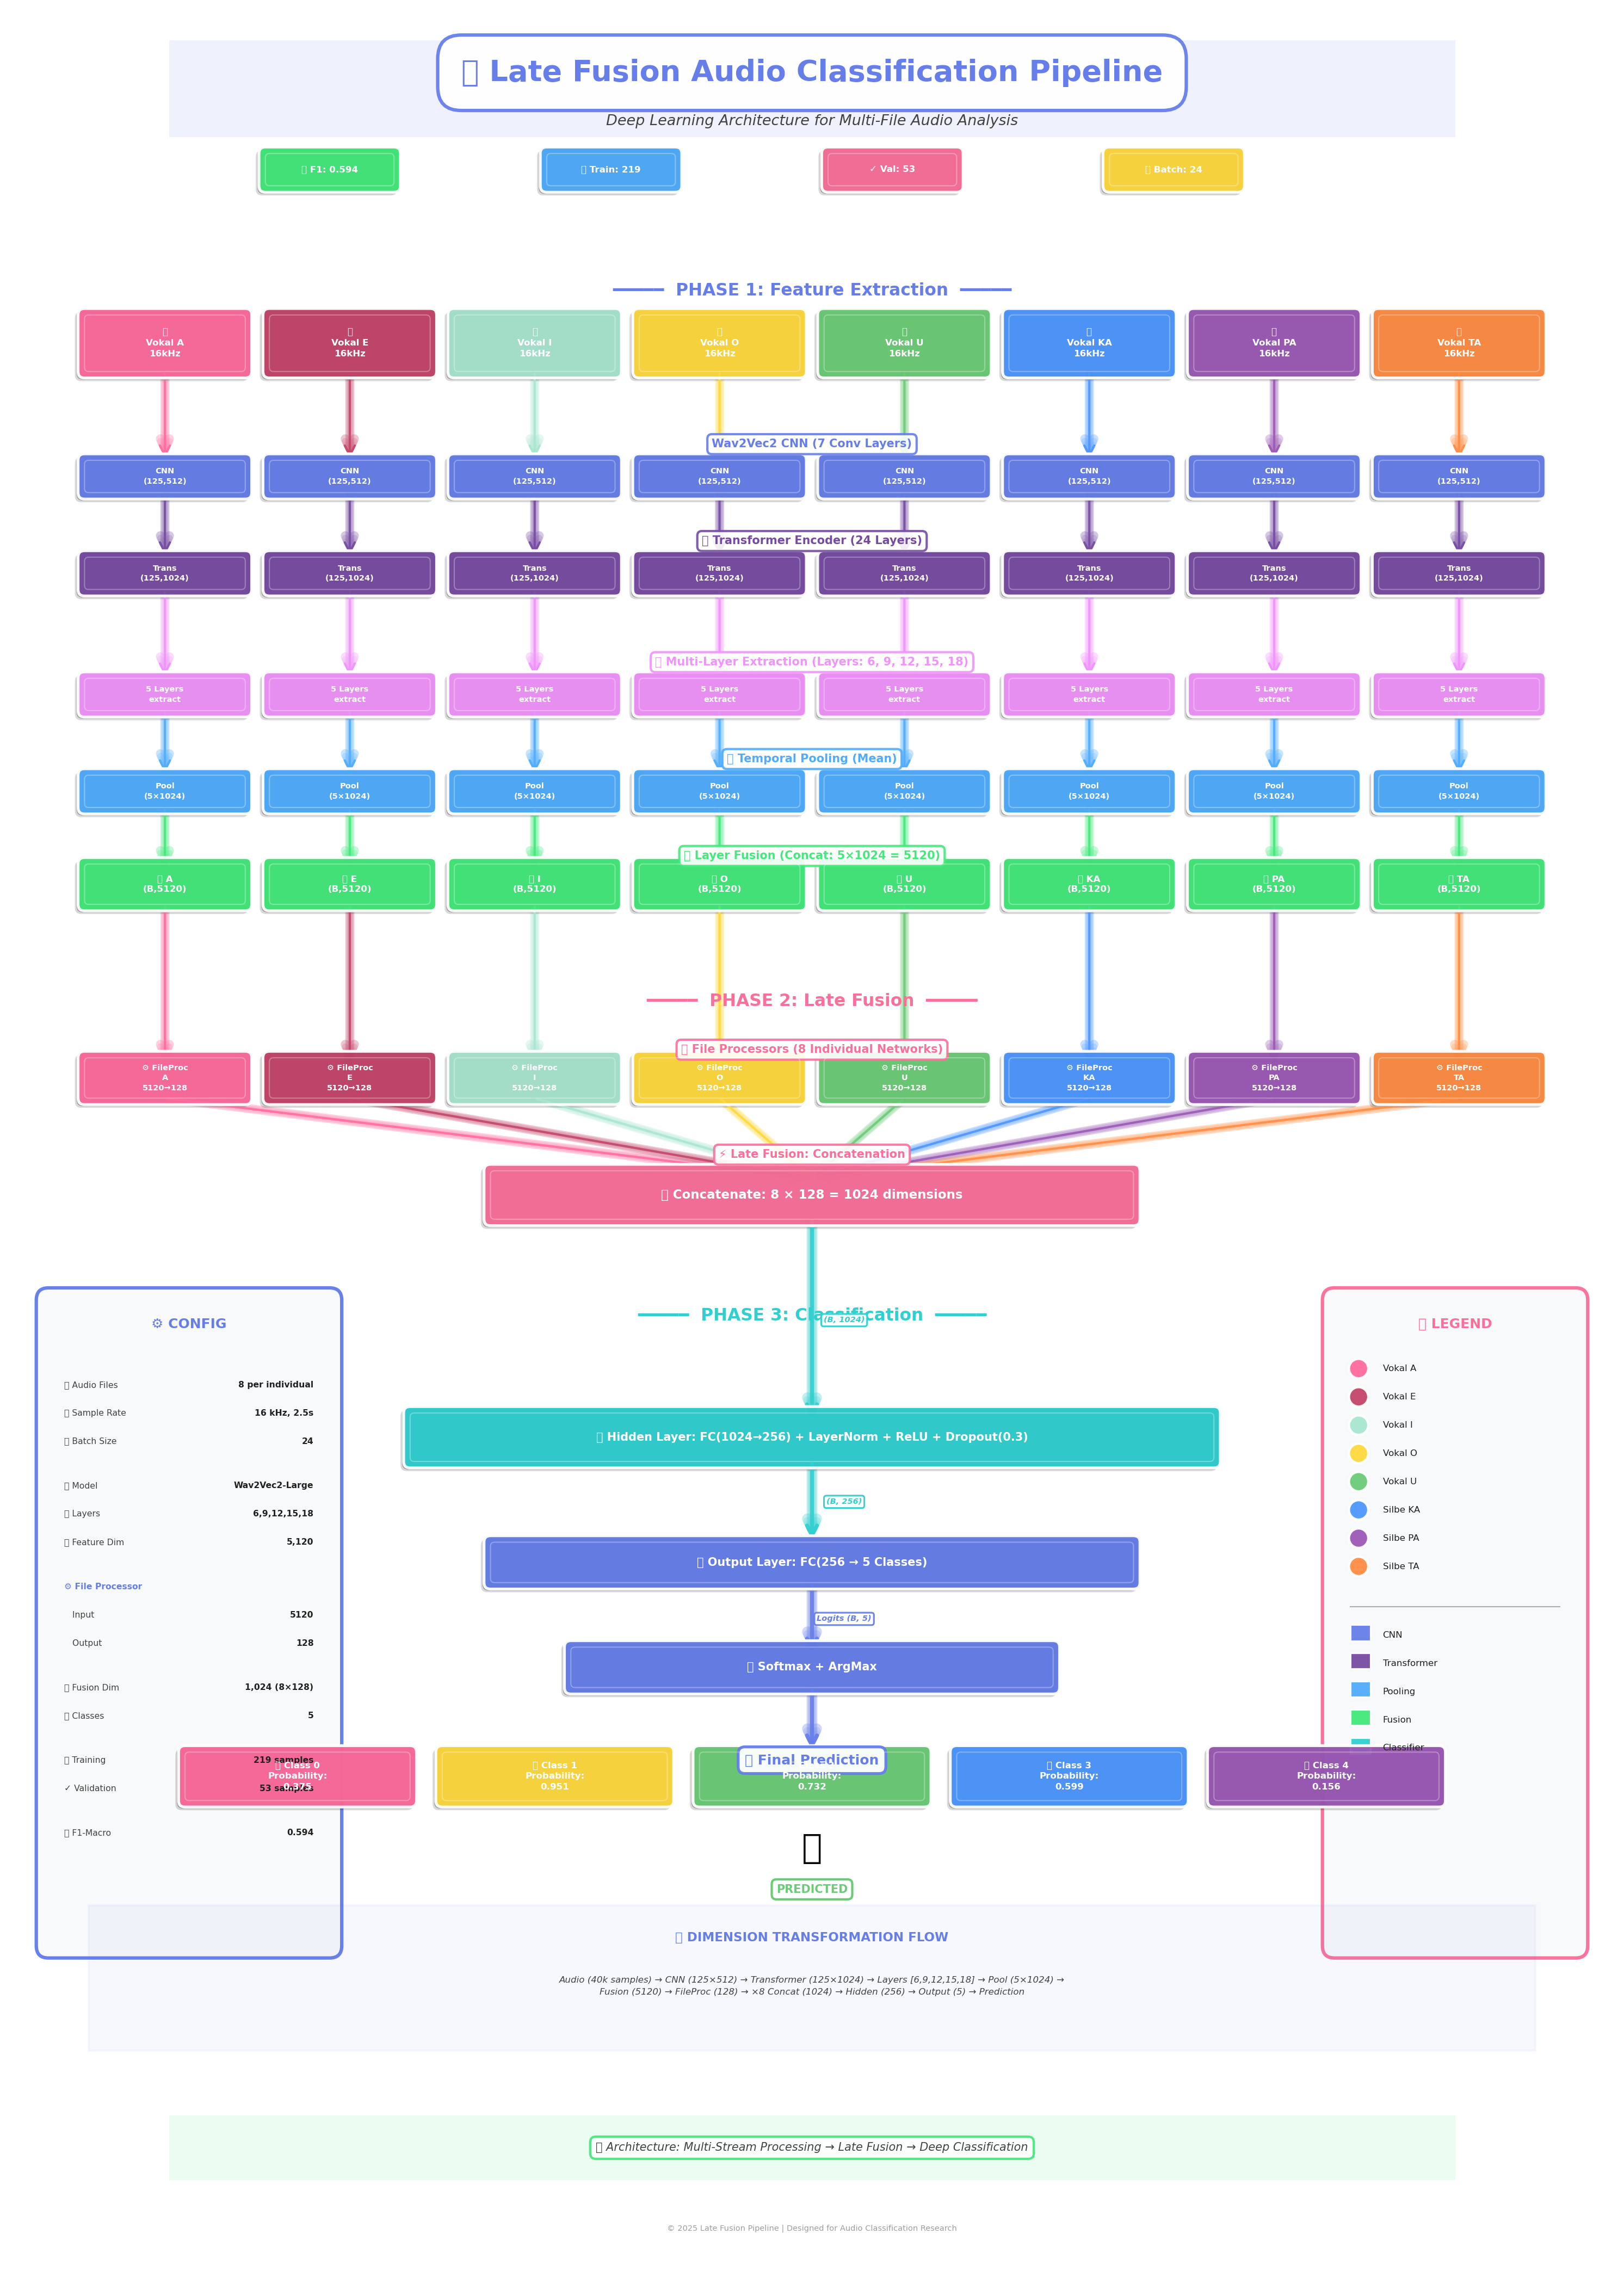

In [75]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle
import numpy as np
from matplotlib.path import Path
import matplotlib.patches as patches

# Set up the figure with high DPI for quality
fig, ax = plt.subplots(figsize=(20, 28), dpi=150)
ax.set_xlim(0, 20)
ax.set_ylim(0, 28)
ax.axis('off')

# Ultra-modern color palette - Vibrant gradients
colors = {
    'audio_A': '#FF6B9D',    # Pink
    'audio_E': '#C44569',    # Rose
    'audio_I': '#A8E6CF',    # Mint
    'audio_O': '#FFD93D',    # Yellow
    'audio_U': '#6BCB77',    # Green
    'audio_KA': '#4D96FF',   # Blue
    'audio_PA': '#9B59B6',   # Purple
    'audio_TA': '#FF8C42',   # Orange
    
    'cnn': '#667EEA',        # Indigo
    'transformer': '#764BA2', # Deep purple
    'layer': '#F093FB',      # Light purple
    'pooling': '#4FACFE',    # Sky blue
    'fusion': '#43E97B',     # Bright green
    'concat': '#FA709A',     # Pink gradient
    'classifier': '#30CFD0', # Cyan
    'output': '#667EEA',     # Indigo
}

# Helper function for ultra-modern boxes with gradient effect
def create_ultra_modern_box(ax, x, y, width, height, text, color, 
                           fontsize=9, icon='', alpha=0.95):
    # Gradient effect with multiple layers
    for i in range(3):
        offset = i * 0.02
        alpha_layer = 0.15 * (3 - i)
        shadow = FancyBboxPatch((x - offset, y - offset), width, height,
                               boxstyle="round,pad=0.08",
                               edgecolor='none', facecolor='black',
                               alpha=alpha_layer, zorder=1)
        ax.add_patch(shadow)
    
    # Main box with border
    box = FancyBboxPatch((x, y), width, height,
                        boxstyle="round,pad=0.08",
                        edgecolor='white', facecolor=color,
                        linewidth=2.5, alpha=alpha, zorder=2)
    ax.add_patch(box)
    
    # Inner glow effect
    inner_box = FancyBboxPatch((x + 0.05, y + 0.05), width - 0.1, height - 0.1,
                              boxstyle="round,pad=0.05",
                              edgecolor='white', facecolor='none',
                              linewidth=1, alpha=0.3, zorder=3)
    ax.add_patch(inner_box)
    
    # Icon + Text
    full_text = f'{icon} {text}' if icon else text
    ax.text(x + width/2, y + height/2, full_text,
           ha='center', va='center', fontsize=fontsize,
           fontweight='bold', color='white', zorder=4,
           linespacing=1.4)

# Helper for animated arrows with glow
def create_glow_arrow(ax, x1, y1, x2, y2, color, linewidth=2.5, label=''):
    # Glow effect
    for i in range(3, 0, -1):
        glow = FancyArrowPatch((x1, y1), (x2, y2),
                              arrowstyle='->', mutation_scale=20,
                              color=color, linewidth=linewidth + i*2,
                              alpha=0.1 * i, zorder=0)
        ax.add_patch(glow)
    
    # Main arrow
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                          arrowstyle='->', mutation_scale=22,
                          color=color, linewidth=linewidth,
                          alpha=0.9, zorder=1)
    ax.add_patch(arrow)
    
    # Label with glow background
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        # Calculate offset based on arrow direction
        dx, dy = x2 - x1, y2 - y1
        if abs(dx) > abs(dy):  # Horizontal arrow
            offset_x, offset_y = 0, 0.25
        else:  # Vertical arrow
            offset_x, offset_y = 0.4, 0
            
        ax.text(mid_x + offset_x, mid_y + offset_y, label,
               ha='center', va='center', fontsize=7,
               style='italic', color=color, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='white', edgecolor=color,
                        linewidth=1.5, alpha=0.95))

# ========================================================================
# TITLE SECTION
# ========================================================================
title_y = 27
# Gradient title background
title_bg = Rectangle((2, title_y - 0.6), 16, 1.2,
                     facecolor='#667EEA', alpha=0.1, zorder=0)
ax.add_patch(title_bg)

ax.text(10, title_y + 0.2, '🎵 Late Fusion Audio Classification Pipeline',
        ha='center', va='center', fontsize=26, fontweight='bold',
        color='#667EEA',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white',
                 edgecolor='#667EEA', linewidth=3, alpha=0.95))

ax.text(10, title_y - 0.4, 'Deep Learning Architecture for Multi-File Audio Analysis',
        ha='center', va='center', fontsize=13, style='italic',
        color='#424242')

# Performance badges
badge_data = [
    ('🎯 F1: 0.594', 4, '#43E97B'),
    ('📊 Train: 219', 7.5, '#4FACFE'),
    ('✓ Val: 53', 11, '#FA709A'),
    ('🔢 Batch: 24', 14.5, '#FFD93D'),
]

for text, x_pos, color in badge_data:
    create_ultra_modern_box(ax, x_pos - 0.8, title_y - 1.2, 1.6, 0.4,
                           text, color, fontsize=8)

# ========================================================================
# PHASE 1: 8 AUDIO INPUTS
# ========================================================================
phase1_y = 24.5
ax.text(10, phase1_y, '━━━━━  PHASE 1: Feature Extraction  ━━━━━',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color='#667EEA')

# 8 Audio files in a row
audio_y = 23.5
audio_files = [
    ('A', 'audio_A', '🎤'),
    ('E', 'audio_E', '🎤'),
    ('I', 'audio_I', '🎤'),
    ('O', 'audio_O', '🎤'),
    ('U', 'audio_U', '🎤'),
    ('KA', 'audio_KA', '🎙️'),
    ('PA', 'audio_PA', '🎙️'),
    ('TA', 'audio_TA', '🎙️'),
]

box_width = 2.0
spacing = 0.3
start_x = 10 - (8 * box_width + 7 * spacing) / 2

for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, audio_y, box_width, 0.7,
                           f'{icon}\nVokal {name}\n16kHz',
                           colors[color_key], fontsize=8)

# ========================================================================
# CNN PROCESSING (8 parallel streams)
# ========================================================================
cnn_y = 22.0
ax.text(10, cnn_y + 0.6, 'Wav2Vec2 CNN (7 Conv Layers)', 
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#667EEA',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#667EEA', linewidth=2, alpha=0.9))

# Arrows from audio to CNN
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, audio_y, x, cnn_y + 0.4, colors[color_key], 2)

# 8 CNN boxes
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, cnn_y, box_width, 0.4,
                           f'CNN\n(125,512)',
                           colors['cnn'], fontsize=7)

# ========================================================================
# TRANSFORMER (24 Layers) - 8 parallel
# ========================================================================
transformer_y = 20.8
ax.text(10, transformer_y + 0.6, '🔄 Transformer Encoder (24 Layers)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#764BA2',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#764BA2', linewidth=2, alpha=0.9))

# Arrows from CNN to Transformer
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, cnn_y, x, transformer_y + 0.4,
                     colors['transformer'], 2)

# 8 Transformer boxes
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, transformer_y, box_width, 0.4,
                           f'Trans\n(125,1024)',
                           colors['transformer'], fontsize=7)

# ========================================================================
# MULTI-LAYER EXTRACTION (5 Layers per audio)
# ========================================================================
layer_y = 19.3
ax.text(10, layer_y + 0.6, '🎯 Multi-Layer Extraction (Layers: 6, 9, 12, 15, 18)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#F093FB',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#F093FB', linewidth=2, alpha=0.9))

# Show simplified: Just indicate extraction happens
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, transformer_y, x, layer_y + 0.4,
                     colors['layer'], 2)

# 8 Layer extraction indicators
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, layer_y, box_width, 0.4,
                           f'5 Layers\nextract',
                           colors['layer'], fontsize=7)

# ========================================================================
# TEMPORAL POOLING (Mean over time)
# ========================================================================
pooling_y = 18.1
ax.text(10, pooling_y + 0.6, '⏱️ Temporal Pooling (Mean)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#4FACFE',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#4FACFE', linewidth=2, alpha=0.9))

# Arrows from layers to pooling
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, layer_y, x, pooling_y + 0.4,
                     colors['pooling'], 2)

# 8 Pooling boxes
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, pooling_y, box_width, 0.4,
                           f'Pool\n(5×1024)',
                           colors['pooling'], fontsize=7)

# ========================================================================
# LAYER FUSION (Concatenation per audio)
# ========================================================================
fusion_layer_y = 16.9
ax.text(10, fusion_layer_y + 0.6, '🔗 Layer Fusion (Concat: 5×1024 = 5120)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#43E97B',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#43E97B', linewidth=2, alpha=0.9))

# Arrows from pooling to fusion
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, pooling_y, x, fusion_layer_y + 0.4,
                     colors['fusion'], 2)

# 8 Fusion boxes (one per audio file)
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, fusion_layer_y, box_width, 0.5,
                           f'{name}\n(B,5120)',
                           colors['fusion'], fontsize=8, icon='✨')

# ========================================================================
# PHASE 2: FILE PROCESSORS
# ========================================================================
phase2_y = 15.7
ax.text(10, phase2_y, '━━━━━  PHASE 2: Late Fusion  ━━━━━',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color='#FA709A')

# FILE PROCESSORS (8 separate networks)
fileproc_y = 14.5
ax.text(10, fileproc_y + 0.6, '🔧 File Processors (8 Individual Networks)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#FA709A',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#FA709A', linewidth=2, alpha=0.9))

# Arrows from fusion to file processors
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x, fusion_layer_y, x, fileproc_y + 0.4,
                     colors[color_key], 2)

# 8 File processor boxes
for i, (name, color_key, icon) in enumerate(audio_files):
    x = start_x + i * (box_width + spacing)
    create_ultra_modern_box(ax, x, fileproc_y, box_width, 0.5,
                           f'FileProc\n{name}\n5120→128',
                           colors[color_key], fontsize=7, icon='⚙️')

# ========================================================================
# CONCATENATION (Late Fusion)
# ========================================================================
concat_y = 13.0
ax.text(10, concat_y + 0.8, '⚡ Late Fusion: Concatenation',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#FA709A',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor='#FA709A', linewidth=2, alpha=0.9))

# Arrows converging from all 8 file processors
for i, (name, color_key, icon) in enumerate(audio_files):
    x_start = start_x + i * (box_width + spacing) + box_width/2
    create_glow_arrow(ax, x_start, fileproc_y, 10, concat_y + 0.5,
                     colors[color_key], 2)

# Concatenation box
create_ultra_modern_box(ax, 6, concat_y, 8, 0.6,
                       '🔀 Concatenate: 8 × 128 = 1024 dimensions',
                       colors['concat'], fontsize=11, icon='')

# ========================================================================
# PHASE 3: CLASSIFICATION
# ========================================================================
phase3_y = 11.8
ax.text(10, phase3_y, '━━━━━  PHASE 3: Classification  ━━━━━',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color='#30CFD0')

# Arrow to classifier
create_glow_arrow(ax, 10, concat_y, 10, 10.5,
                 colors['classifier'], 3.5, '(B, 1024)')

# ========================================================================
# HIDDEN LAYER
# ========================================================================
hidden_y = 10.0
create_ultra_modern_box(ax, 5, hidden_y, 10, 0.6,
                       '🧠 Hidden Layer: FC(1024→256) + LayerNorm + ReLU + Dropout(0.3)',
                       colors['classifier'], fontsize=10)

create_glow_arrow(ax, 10, hidden_y, 10, hidden_y - 1.0,
                 colors['classifier'], 3.5, '(B, 256)')

# ========================================================================
# OUTPUT LAYER
# ========================================================================
output_y = 8.5
create_ultra_modern_box(ax, 6, output_y, 8, 0.5,
                       '📤 Output Layer: FC(256 → 5 Classes)',
                       colors['output'], fontsize=10)

create_glow_arrow(ax, 10, output_y, 10, output_y - 0.9,
                 colors['output'], 3.5, 'Logits (B, 5)')

# ========================================================================
# SOFTMAX & PREDICTION
# ========================================================================
softmax_y = 7.2
create_ultra_modern_box(ax, 7, softmax_y, 6, 0.5,
                       '🎲 Softmax + ArgMax',
                       '#667EEA', fontsize=10)

create_glow_arrow(ax, 10, softmax_y, 10, softmax_y - 0.8,
                 '#667EEA', 3.5, '')

# ========================================================================
# FINAL PREDICTION (5 Classes)
# ========================================================================
prediction_y = 5.8
ax.text(10, prediction_y + 0.5, '✨ Final Prediction',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='#667EEA',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                 edgecolor='#667EEA', linewidth=2.5, alpha=0.95))

# 5 Class boxes
class_colors = ['#FF6B9D', '#FFD93D', '#6BCB77', '#4D96FF', '#9B59B6']
class_width = 2.8
class_spacing = 0.4
class_start_x = 10 - (5 * class_width + 4 * class_spacing) / 2

for i in range(5):
    x = class_start_x + i * (class_width + class_spacing)
    create_ultra_modern_box(ax, x, prediction_y, class_width, 0.6,
                           f'Class {i}\nProbability:\n{np.random.rand():.3f}',
                           class_colors[i], fontsize=8, icon='📊')

# Winner indicator
winner_class = 2  # Example: Class 2 wins
winner_x = class_start_x + winner_class * (class_width + class_spacing) + class_width/2

# Trophy
ax.text(winner_x, prediction_y - 0.6, '🏆',
        ha='center', va='center', fontsize=30)
ax.text(winner_x, prediction_y - 1.1, 'PREDICTED',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color=class_colors[winner_class],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                 edgecolor=class_colors[winner_class], linewidth=2))

# ========================================================================
# INFO PANEL (Left side)
# ========================================================================
info_x = 0.5
info_y = 12

# Modern panel with gradient border
info_panel = FancyBboxPatch((info_x, info_y - 8), 3.5, 8,
                           boxstyle="round,pad=0.15",
                           edgecolor='#667EEA', facecolor='#F8F9FA',
                           linewidth=3, alpha=0.98, zorder=0)
ax.add_patch(info_panel)

ax.text(info_x + 1.75, info_y - 0.3, '⚙️ CONFIG',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='#667EEA')

config_items = [
    ('', '', True),
    ('🎵 Audio Files', '8 per individual', False),
    ('📊 Sample Rate', '16 kHz, 2.5s', False),
    ('🔢 Batch Size', '24', False),
    ('', '', True),
    ('🤖 Model', 'Wav2Vec2-Large', False),
    ('📐 Layers', '6,9,12,15,18', False),
    ('🔗 Feature Dim', '5,120', False),
    ('', '', True),
    ('⚙️ File Processor', '', False),
    ('   Input', '5120', False),
    ('   Output', '128', False),
    ('', '', True),
    ('🎯 Fusion Dim', '1,024 (8×128)', False),
    ('📊 Classes', '5', False),
    ('', '', True),
    ('📚 Training', '219 samples', False),
    ('✓ Validation', '53 samples', False),
    ('', '', True),
    ('🎯 F1-Macro', '0.594', False),
]

y_pos = info_y - 0.8
for label, value, is_spacer in config_items:
    if is_spacer:
        y_pos -= 0.2
        continue
    
    if value:
        ax.text(info_x + 0.2, y_pos, label,
               ha='left', va='top', fontsize=7.5, color='#424242')
        ax.text(info_x + 3.3, y_pos, value,
               ha='right', va='top', fontsize=7.5, fontweight='bold',
               color='#212121')
    else:
        ax.text(info_x + 0.2, y_pos, label,
               ha='left', va='top', fontsize=7.5, fontweight='bold',
               color='#667EEA')
    
    y_pos -= 0.35

# ========================================================================
# LEGEND (Right side)
# ========================================================================
legend_x = 16.5
legend_y = 12

legend_panel = FancyBboxPatch((legend_x, legend_y - 8), 3.0, 8,
                             boxstyle="round,pad=0.15",
                             edgecolor='#FA709A', facecolor='#F8F9FA',
                             linewidth=3, alpha=0.98, zorder=0)
ax.add_patch(legend_panel)

ax.text(legend_x + 1.5, legend_y - 0.3, '🎨 LEGEND',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='#FA709A')

legend_items = [
    ('Vokal A', 'audio_A'),
    ('Vokal E', 'audio_E'),
    ('Vokal I', 'audio_I'),
    ('Vokal O', 'audio_O'),
    ('Vokal U', 'audio_U'),
    ('Silbe KA', 'audio_KA'),
    ('Silbe PA', 'audio_PA'),
    ('Silbe TA', 'audio_TA'),
]

y_pos = legend_y - 0.8
for label, color_key in legend_items:
    # Color indicator circle
    circle = Circle((legend_x + 0.3, y_pos - 0.05), 0.12,
                   facecolor=colors[color_key], edgecolor='white',
                   linewidth=2, alpha=0.95, zorder=2)
    ax.add_patch(circle)
    
    ax.text(legend_x + 0.6, y_pos, label,
           ha='left', va='top', fontsize=8, color='#212121')
    
    y_pos -= 0.35

# Separator
y_pos -= 0.2
ax.plot([legend_x + 0.2, legend_x + 2.8], [y_pos, y_pos],
        'k-', linewidth=1, alpha=0.3)
y_pos -= 0.3

# Processing stages
stage_items = [
    ('CNN', 'cnn'),
    ('Transformer', 'transformer'),
    ('Pooling', 'pooling'),
    ('Fusion', 'fusion'),
    ('Classifier', 'classifier'),
]

for label, color_key in stage_items:
    rect = Rectangle((legend_x + 0.2, y_pos - 0.12), 0.25, 0.2,
                    facecolor=colors[color_key], edgecolor='white',
                    linewidth=1.5, alpha=0.95)
    ax.add_patch(rect)
    
    ax.text(legend_x + 0.6, y_pos, label,
           ha='left', va='top', fontsize=8, color='#212121')
    
    y_pos -= 0.35

# ========================================================================
# DIMENSION FLOW SUMMARY (Bottom)
# ========================================================================
summary_y = 3.5
summary_bg = Rectangle((1, summary_y - 0.8), 18, 1.8,
                       facecolor='#667EEA', alpha=0.05,
                       edgecolor='#667EEA', linewidth=2)
ax.add_patch(summary_bg)

ax.text(10, summary_y + 0.6, '📐 DIMENSION TRANSFORMATION FLOW',
        ha='center', va='center', fontsize=11, fontweight='bold',
        color='#667EEA')

flow_text = (
    'Audio (40k samples) → CNN (125×512) → Transformer (125×1024) → '
    'Layers [6,9,12,15,18] → Pool (5×1024) →\n'
    'Fusion (5120) → FileProc (128) → ×8 Concat (1024) → '
    'Hidden (256) → Output (5) → Prediction'
)

ax.text(10, summary_y, flow_text,
        ha='center', va='center', fontsize=8, style='italic',
        color='#424242', linespacing=1.6)

# ========================================================================
# FOOTER
# ========================================================================
footer_y = 1.5
footer_bg = Rectangle((2, footer_y - 0.4), 16, 0.8,
                     facecolor='#43E97B', alpha=0.1)
ax.add_patch(footer_bg)

ax.text(10, footer_y, '🚀 Architecture: Multi-Stream Processing → Late Fusion → Deep Classification',
        ha='center', va='center', fontsize=10, style='italic',
        color='#424242',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                 edgecolor='#43E97B', linewidth=2, alpha=0.95))

# Copyright
ax.text(10, 0.5, '© 2025 Late Fusion Pipeline | Designed for Audio Classification Research',
        ha='center', va='center', fontsize=7, color='#9E9E9E')

plt.tight_layout()
plt.savefig('late_fusion_complete_flow_ultra_modern.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig('late_fusion_complete_flow_ultra_modern.pdf',
            bbox_inches='tight', facecolor='white')

print("✨ Ultra-modern pipeline visualization created!")
print("\n📄 Files saved:")
print("   • late_fusion_complete_flow_ultra_modern.png")
print("   • late_fusion_complete_flow_ultra_modern.pdf")
print("\n🎨 Design features:")
print("   ✓ Complete flow: 8 audio files → classification")
print("   ✓ Individual color coding for each audio file")
print("   ✓ Glow effects and gradient shadows")
print("   ✓ Modern, vibrant color palette")
print("   ✓ Clean vertical flow")
print("   ✓ Detailed dimension annotations")
print("   ✓ Professional info panels")
print("\n📊 Dimensions: 20×28 inches @ 150 DPI")

plt.show()